In [3]:
"""BLOCK 1: SETUP"""

# Required packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import warnings

# Print package versions for reproducibility
print("="*80)
print("Package Versions (for reproducibility):")
print(f"  NumPy: {np.__version__}")
print(f"  Matplotlib: {plt.matplotlib.__version__}")
import scipy
print(f"  SciPy: {scipy.__version__}")
print("="*80)
print()

warnings.filterwarnings('ignore')

# Global configuration
RANDOM_SEED = 42
EQUILIBRIUM_THRESHOLD = 0.9  # Threshold for classifying pure strategy equilibria
np.random.seed(RANDOM_SEED)

# Simulation parameters
SIMULATION_TIME = 50      # Time units for replicator dynamics
SIMULATION_DT = 0.1       # Time step for numerical integration
BASIN_TRIALS = 100000     # Number of trials for empirical basin measurement

# Matplotlib settings
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Helper functions
def print_section_header(title: str, description: str = "") -> None:
    """Print formatted section header for notebook organization."""
    print("\n" + "="*80)
    print(title.upper())
    print("="*80)
    if description:
        print(description)
        print()

print(f"Setup complete (random seed: {RANDOM_SEED})")

Package Versions (for reproducibility):
  NumPy: 2.2.5
  Matplotlib: 3.8.4
  SciPy: 1.14.1

Setup complete (random seed: 42)


In [4]:
"""BLOCK 2: GENERAL N-GAME COORDINATION MODEL"""

class NGameCoordinationSystem:
    """
    System of n coordination games with linear interdependence structure.
    
    Each game i is a coordination game where:
    - Strategy A yields: α_i · P(meet A-player in game i)
    - Strategy B yields: β · P(meet B-player in game i)
    
    The payoff parameter α_i depends linearly on neighboring games:
        α_i = a · (mean of neighbors' x values) + c
    
    where x_j is the proportion playing A in game j.
    
    Network Structure:
    - Ring topology: each game depends on its immediate neighbors
    - For n=1: α = c (independent game, no neighbors)
    - For n=2: α_1 = a·x_2 + c, α_2 = a·x_1 + c
    - For n≥3: α_i = a·(x_{i-1} + x_{i+1})/2 + c
    
    Internal Mechanisms:
    - Within-game correlation (r): Positive assortment within each game
    - Conditional cooperation: Strategy C that switches when threshold is met
    
    Parameters:
    -----------
    n_games : int
        Number of coordination games in the system
    alpha_coupling : float
        Interdependence strength parameter 'a' (a ≥ 0)
        When a = 0: games are independent
        When a > 0: games are interdependent
    constant : float
        Independent value parameter 'c' (c ≥ 0)
   

 beta : float
        Payoff for B-coordination (held constant, default β = 1)
    within_correlation : float
        Degree of positive assortment within each game, r ∈ [0,1]
        r = 0: random matching (standard replicator dynamics)
        r = 1: perfect assortment (always meet own type)
    network_type : str
        Topology of interdependencies (default: 'ring')
    """
    
    def __init__(self, 
                 n_games: int,
                 alpha_coupling: float,
                 constant: float,
                 beta: float = 1.0,
                 within_correlation: float = 0.0,
                 network_type: str = 'ring'):
        
        # Validation
        if n_games < 1:
            raise ValueError("Must have at least 1 game")
        if alpha_coupling < 0:
            raise ValueError("Alpha coupling must be non-negative")
        if constant < 0:
            raise ValueError("Constant must be non-negative")
        if beta <= 0:
            raise ValueError("Beta must be positive")
        if not 0 <= within_correlation <= 1:
            raise ValueError("Within-game correlation must be in [0,1]")
        if network_type != 'ring':
            raise ValueError("Only 'ring' topology currently supported")
        
        self.n = n_games
        self.a = alpha_coupling
        self.c = constant
        self.beta = beta
        self.r = within_correlation
        self.network_type = network_type
    
    def compute_alpha(self, x: np.ndarray, game_idx: int) -> float:
        """
        Compute α_i for game i given current state vector x.
        
        For ring topology:
        - n=1: α = c (no neighbors)
        - n=2: α_i = a·x_j + c (where j is the other game)
        - n≥3: α_i = a·(x_{i-1} + x_{i+1})/2 + c (periodic boundaries)
        """
        if self.n == 1:
            return self.c
        elif self.n == 2:
            other_idx = 1 - game_idx
            return self.a * x[other_idx] + self.c
        else:
            # Ring topology with periodic boundaries
            left_neighbor = x[(game_idx - 1) % self.n]
            right_neighbor = x[(game_idx + 1) % self.n]
            return self.a * (left_neighbor + right_neighbor) / 2 + self.c
    
    def fitness_A(self, x: np.ndarray, game_idx: int) -> float:
        """
        Expected fitness of strategy A in game i.
        
        With correlation r, an A-player in game i meets another A-player
        with probability: r + (1-r)·x_i
        """
        alpha_i = self.compute_alpha(x, game_idx)
        x_i = x[game_idx]
        prob_meet_A = self.r + (1 - self.r) * x_i
        return alpha_i * prob_meet_A
    
    def fitness_B(self, x: np.ndarray, game_idx: int) -> float:
        """
        Expected fitness of strategy B in game i.
        
        With correlation r, a B-player in game i meets another B-player
        with probability: r + (1-r)·(1 - x_i)
        """
        x_i = x[game_idx]
        prob_meet_B = self.r + (1 - self.r) * (1 - x_i)
        return self.beta * prob_meet_B
    
    def replicator_dynamics(self, x: np.ndarray, t: float) -> np.ndarray:
        """
        Coupled replicator dynamics for all n games.
        
        For each game i:
            dx_i/dt = x_i(1 - x_i)(f_A^i - f_B^i)
        
        Parameters:
        -----------
        x : ndarray of length n
            Current state vector (proportion playing A in each game)
        t : float
            Time (required by odeint interface, not used)
        
        Returns:
        --------
        dx : ndarray of length n
            Time derivatives for all games
        """
        dx = np.zeros(self.n)
        
        for i in range(self.n):
            x_i = x[i]
            f_A = self.fitness_A(x, i)
            f_B = self.fitness_B(x, i)
            dx[i] = x_i * (1 - x_i) * (f_A - f_B)
        
        return dx
    
    def simulate(self, x0: np.ndarray, T: float = SIMULATION_TIME, 
                 dt: float = SIMULATION_DT) -> tuple[np.ndarray, np.ndarray]:
        """
        Simulate coupled replicator dynamics from initial state.
        
        Parameters:
        -----------
        x0 : ndarray of length n
            Initial state (proportion playing A in each game)
        T : float
            Total simulation time
        dt : float
            Time step for output
        
        Returns:
        --------
        t : ndarray
            Time points
        x : ndarray of shape (len(t), n)
            State trajectory
        """
        if len(x0) != self.n:
            raise ValueError(f"Initial state must have length {self.n}")
        if not np.all((x0 >= 0) & (x0 <= 1)):
            raise ValueError("Initial state must have all values in [0,1]")
        
        t = np.arange(0, T, dt)
        x = odeint(self.replicator_dynamics, x0, t)
        return t, x
    
    def classify_outcome(self, x_final: np.ndarray, 
                        threshold: float = EQUILIBRIUM_THRESHOLD) -> str:
        """
        Classify final system state.
        
        Returns:
        --------
        'All-A' : All games converged to A
        'All-B' : All games converged to B
        'Fragmented' : Some games at A, others at B
        'Mixed' : At least one game in mixed equilibrium
        """
        classifications = []
        for x_i in x_final:
            if x_i > threshold:
                classifications.append('A')
            elif x_i < (1 - threshold):
                classifications.append('B')
            else:
                classifications.append('Mixed')
        
        if all(c == 'Mixed' for c in classifications):
            return 'Mixed'
        if 'Mixed' in classifications:
            return 'Mixed'
        if all(c == 'A' for c in classifications):
            return 'All-A'
        if all(c == 'B' for c in classifications):
            return 'All-B'
        return 'Fragmented'

    def measure_basins(self, n_trials: int = 10000, 
                       seed: int | None = None) -> dict:
        """
        Empirically measure basins of attraction via Monte Carlo sampling.
        
        Samples random initial conditions uniformly from [0,1]^n and simulates
        each to equilibrium, classifying the final outcome.
        
        Parameters:
        -----------
        n_trials : int
            Number of random initial conditions to test
        seed : int or None
            Random seed for reproducibility
        
        Returns:
        --------
        dict with keys:
            'All-A': proportion converging to All-A
            'All-B': proportion converging to All-B  
            'Fragmented': proportion with mixed outcomes across games
            'Mixed': proportion with mixed equilibria within games
            'n_trials': number of trials run
        """
        if seed is not None:
            np.random.seed(seed)
        
        outcomes = {'All-A': 0, 'All-B': 0, 'Fragmented': 0, 'Mixed': 0}
        
        for _ in range(n_trials):
            x0 = np.random.uniform(0, 1, self.n)
            t, x = self.simulate(x0)
            outcome = self.classify_outcome(x[-1])
            outcomes[outcome] += 1
        
        # Convert to proportions
        results = {k: v / n_trials for k, v in outcomes.items()}
        results['n_trials'] = n_trials
        
        return results   


VALIDATION: N=1 INDEPENDENT GAME
Verify that n=1 case reproduces standard coordination game results

Single coordination game: α = 1.1, β = 1.0
  Theoretical basin of All-A: 52.4%
  Theoretical unstable point: 0.476

Empirical results (N = 100,000 trials):
  All-A: 52.4%
  All-B: 47.6%
  Mixed: 0.0%

  Absolute error: 0.0002
  Relative error: 0.04%

Generating phase portrait...


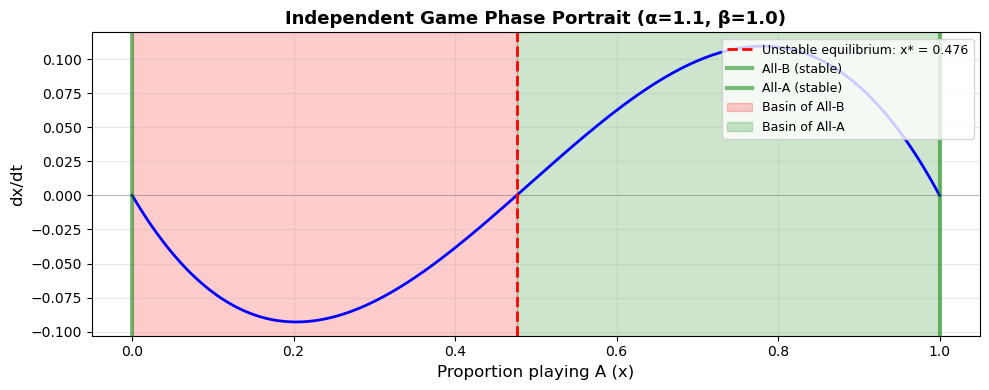


✓ Validation complete: n=1 case matches standard theory


In [8]:
"""BLOCK 3: VALIDATION - INDEPENDENT GAME (n=1)"""

print_section_header(
    "Validation: n=1 Independent Game",
    "Verify that n=1 case reproduces standard coordination game results"
)

# Test case: α = 1.1, β = 1 (as in paper Figure 2)
alpha_test = 1.1
beta_test = 1.0

# Create single-game system (no interdependence when n=1)
model_single = NGameCoordinationSystem(
    n_games=1,
    alpha_coupling=0.0,  # Coupling irrelevant for n=1
    constant=alpha_test,  # α = c when n=1
    beta=beta_test,
    within_correlation=0.0
)

print(f"Single coordination game: α = {alpha_test}, β = {beta_test}")

# Theoretical prediction
theoretical_basin_A = alpha_test / (alpha_test + beta_test)
theoretical_unstable = beta_test / (alpha_test + beta_test)

print(f"  Theoretical basin of All-A: {theoretical_basin_A:.1%}")
print(f"  Theoretical unstable point: {theoretical_unstable:.3f}")

# Empirical measurement
results_single = model_single.measure_basins(n_trials=BASIN_TRIALS, seed=RANDOM_SEED)

print(f"\nEmpirical results (N = {results_single['n_trials']:,} trials):")
print(f"  All-A: {results_single['All-A']:.1%}")
print(f"  All-B: {results_single['All-B']:.1%}")
print(f"  Mixed: {results_single['Mixed']:.1%}")
print(f"\n  Absolute error: {abs(results_single['All-A'] - theoretical_basin_A):.4f}")
print(f"  Relative error: {abs(results_single['All-A'] - theoretical_basin_A)/theoretical_basin_A:.2%}")

# Visualize phase portrait
print("\nGenerating phase portrait...")
x_vals = np.linspace(0, 1, 200)
dx_vals = []

for x_val in x_vals:
    dx = model_single.replicator_dynamics(np.array([x_val]), 0)[0]
    dx_vals.append(dx)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_vals, dx_vals, 'b-', linewidth=2)
ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.axvline(theoretical_unstable, color='r', linestyle='--', linewidth=2,
           label=f'Unstable equilibrium: x* = {theoretical_unstable:.3f}')
ax.axvline(0, color='green', linestyle='-', linewidth=3, alpha=0.5, label='All-B (stable)')
ax.axvline(1, color='green', linestyle='-', linewidth=3, alpha=0.5, label='All-A (stable)')

# Shade basins
ax.axvspan(0, theoretical_unstable, alpha=0.2, color='red', label='Basin of All-B')
ax.axvspan(theoretical_unstable, 1, alpha=0.2, color='green', label='Basin of All-A')

ax.set_xlabel('Proportion playing A (x)', fontsize=12)
ax.set_ylabel('dx/dt', fontsize=12)
ax.set_title(f'Independent Game Phase Portrait (α={alpha_test}, β={beta_test})', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Validation complete: n=1 case matches standard theory")


INTERDEPENDENT GAMES: BASIN SHRINKAGE
Demonstrating that interdependence reduces viability of optimal coordination


Weak coupling, high baseline: a=0.5, c=0.6, β=1
  Independent game (α=0.85):
    Theoretical All-A basin: 45.9%
    Empirical All-A: 46.0%

  Interdependent games:
    All-A: 25.5%
    All-B: 35.1%
    Fragmented: 39.4%
    Mixed: 0.0%

  → Basin reduction: 20.5% (relative: 44.6%)

Strong coupling, low baseline: a=2.0, c=0.01, β=1
  Independent game (α=1.01):
    Theoretical All-A basin: 50.2%
    Empirical All-A: 50.3%

  Interdependent games:
    All-A: 36.4%
    All-B: 59.1%
    Fragmented: 3.8%
    Mixed: 0.7%

  → Basin reduction: 13.9% (relative: 27.6%)

Generating basin comparison visualization...


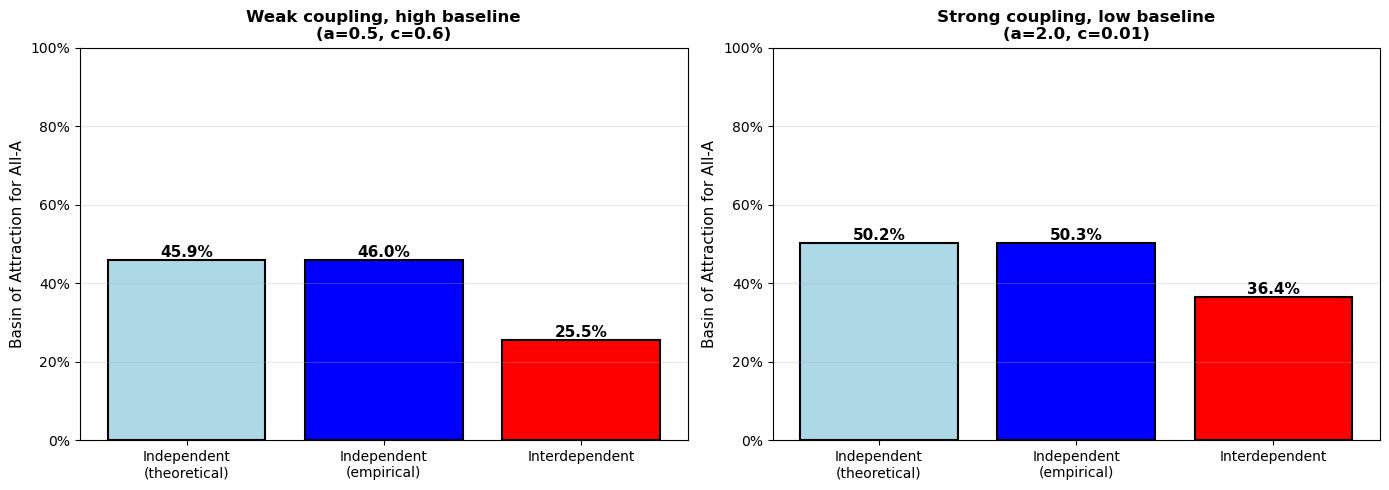


✓ Basin shrinkage demonstrated: interdependence reduces viability


In [9]:
"""BLOCK 4: INTERDEPENDENT GAMES (n=2) - BASIN SHRINKAGE"""

print_section_header(
    "Interdependent Games: Basin Shrinkage",
    "Demonstrating that interdependence reduces viability of optimal coordination"
)

# Test parameters matching paper
test_configs = [
    {'a': 0.5, 'c': 0.6, 'label': 'Weak coupling, high baseline'},
    {'a': 2.0, 'c': 0.01, 'label': 'Strong coupling, low baseline'}
]

comparison_results = []

for config in test_configs:
    print(f"\n{config['label']}: a={config['a']}, c={config['c']}, β=1")
    print("="*60)
    
    # Independent case (n=1)
    alpha_independent = config['a'] * 0.5 + config['c']  # Assume x=0.5 average
    model_indep = NGameCoordinationSystem(
        n_games=1,
        alpha_coupling=0.0,
        constant=alpha_independent,
        beta=1.0,
        within_correlation=0.0
    )
    
    results_indep = model_indep.measure_basins(n_trials=BASIN_TRIALS, seed=RANDOM_SEED)
    theoretical_indep = alpha_independent / (alpha_independent + 1.0)
    
    # Interdependent case (n=2)
    model_inter = NGameCoordinationSystem(
        n_games=2,
        alpha_coupling=config['a'],
        constant=config['c'],
        beta=1.0,
        within_correlation=0.0
    )
    
    results_inter = model_inter.measure_basins(n_trials=BASIN_TRIALS, seed=RANDOM_SEED)
    
    print(f"  Independent game (α={alpha_independent:.2f}):")
    print(f"    Theoretical All-A basin: {theoretical_indep:.1%}")
    print(f"    Empirical All-A: {results_indep['All-A']:.1%}")
    
    print(f"\n  Interdependent games:")
    print(f"    All-A: {results_inter['All-A']:.1%}")
    print(f"    All-B: {results_inter['All-B']:.1%}")
    print(f"    Fragmented: {results_inter['Fragmented']:.1%}")
    print(f"    Mixed: {results_inter['Mixed']:.1%}")
    
    reduction = results_indep['All-A'] - results_inter['All-A']
    print(f"\n  → Basin reduction: {reduction:.1%} (relative: {reduction/results_indep['All-A']:.1%})")
    
    comparison_results.append({
        'config': config,
        'independent': results_indep,
        'interdependent': results_inter,
        'theoretical_indep': theoretical_indep
    })

# Visualize basin comparison
print("\nGenerating basin comparison visualization...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, result in enumerate(comparison_results):
    ax = axes[idx]
    config = result['config']
    
    categories = ['Independent\n(theoretical)', 'Independent\n(empirical)', 'Interdependent']
    all_a_values = [
        result['theoretical_indep'],
        result['independent']['All-A'],
        result['interdependent']['All-A']
    ]
    
    colors = ['lightblue', 'blue', 'red']
    bars = ax.bar(categories, all_a_values, color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels
    for bar, val in zip(bars, all_a_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1%}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_ylabel('Basin of Attraction for All-A', fontsize=11)
    ax.set_title(f"{config['label']}\n(a={config['a']}, c={config['c']})", 
                fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Basin shrinkage demonstrated: interdependence reduces viability")


CORRELATION EFFECTS IN INTERDEPENDENT GAMES
Testing whether within-game correlation helps or hinders under interdependence


Weak coupling: a=0.5, c=0.6
  r=0.0: All-A=24.2%, Fragmented=39.9%
  r=0.2: All-A=24.3%, Fragmented=34.0%
  r=0.4: All-A=24.4%, Fragmented=24.0%
  r=0.6: All-A=24.3%, Fragmented=4.9%
  r=0.8: All-A=22.4%, Fragmented=0.0%
  r=0.9: All-A=17.6%, Fragmented=0.0%

Strong coupling: a=2.0, c=0.6
  r=0.0: All-A=44.6%, Fragmented=27.0%
  r=0.2: All-A=56.0%, Fragmented=15.1%
  r=0.4: All-A=72.2%, Fragmented=0.3%
  r=0.6: All-A=77.5%, Fragmented=0.0%
  r=0.8: All-A=83.1%, Fragmented=0.0%
  r=0.9: All-A=86.4%, Fragmented=0.0%

Generating correlation effects visualization...


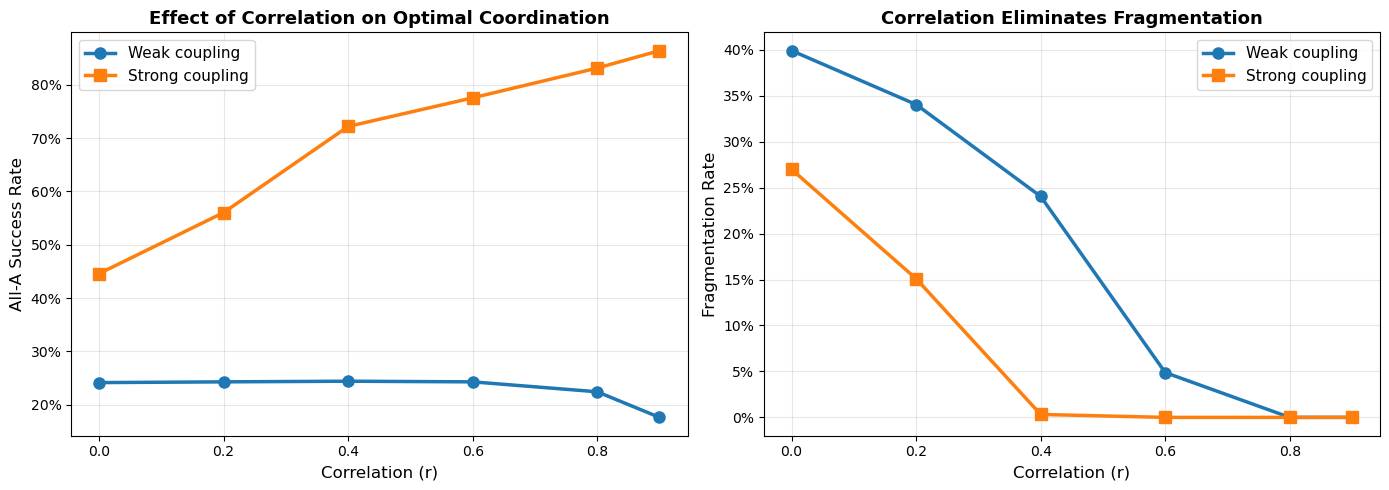


✓ Key finding: Correlation effects depend on coupling strength
  • Weak coupling: correlation reduces All-A success
  • Strong coupling: correlation increases All-A success
  • All regimes: correlation eliminates fragmentation


In [10]:
"""BLOCK 5: CORRELATION EFFECTS IN INTERDEPENDENT GAMES"""

print_section_header(
    "Correlation Effects in Interdependent Games",
    "Testing whether within-game correlation helps or hinders under interdependence"
)

# Test both weak and strong coupling
correlation_configs = [
    {'a': 0.5, 'c': 0.6, 'label': 'Weak coupling', 'marker': 'o'},
    {'a': 2.0, 'c': 0.6, 'label': 'Strong coupling', 'marker': 's'}
]

correlation_levels = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9]
n_trials_correlation = 5000  # Smaller for speed with multiple correlation levels

correlation_results = {}

for config in correlation_configs:
    print(f"\n{config['label']}: a={config['a']}, c={config['c']}")
    print("="*60)
    
    config_results = {}
    
    for r in correlation_levels:
        model = NGameCoordinationSystem(
            n_games=2,
            alpha_coupling=config['a'],
            constant=config['c'],
            beta=1.0,
            within_correlation=r
        )
        
        results = model.measure_basins(n_trials=n_trials_correlation, seed=RANDOM_SEED)
        config_results[r] = results
        
        print(f"  r={r:.1f}: All-A={results['All-A']:.1%}, "
              f"Fragmented={results['Fragmented']:.1%}")
    
    correlation_results[config['label']] = config_results

# Visualize correlation effects
print("\nGenerating correlation effects visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for config in correlation_configs:
    label = config['label']
    results = correlation_results[label]
    
    r_vals = sorted(results.keys())
    all_a = [results[r]['All-A'] for r in r_vals]
    fragmented = [results[r]['Fragmented'] for r in r_vals]
    
    # Plot All-A success
    ax1.plot(r_vals, all_a, marker=config['marker'], markersize=8, 
             linewidth=2.5, label=label)
    
    # Plot fragmentation
    ax2.plot(r_vals, fragmented, marker=config['marker'], markersize=8,
             linewidth=2.5, label=label)

# Format All-A plot
ax1.set_xlabel('Correlation (r)', fontsize=12)
ax1.set_ylabel('All-A Success Rate', fontsize=12)
ax1.set_title('Effect of Correlation on Optimal Coordination', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Format fragmentation plot
ax2.set_xlabel('Correlation (r)', fontsize=12)
ax2.set_ylabel('Fragmentation Rate', fontsize=12)
ax2.set_title('Correlation Eliminates Fragmentation', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

print("\n✓ Key finding: Correlation effects depend on coupling strength")
print("  • Weak coupling: correlation reduces All-A success")
print("  • Strong coupling: correlation increases All-A success")
print("  • All regimes: correlation eliminates fragmentation")

In [11]:
"""BLOCK 6: CONDITIONAL COOPERATION EXTENSION"""

class NGameWithConditionalCooperation(NGameCoordinationSystem):
    """
    Extension of n-game system with conditional cooperation strategy.
    
    Adds a third strategy C (conditional cooperation) that follows the rule:
    "Play A when total commitment (A + C players) reaches threshold θ, 
     otherwise play B"
    
    State representation:
    - For each game i, track: x_A[i], x_C[i]
    - Proportion playing B: x_B[i] = 1 - x_A[i] - x_C[i]
    
    Threshold Dynamics:
    - Below threshold: C-players effectively play B
    - At/above threshold: C-players switch to play A (discontinuous jump)
    
    Parameters:
    -----------
    threshold : float or array-like
        Commitment threshold for triggering C-players' switch
        If float: same threshold for all games
        If array: different threshold per game
        Optimal setting: θ = β/(α + β) for each game
    initial_c_proportion : float or array-like
        Initial proportion of conditional cooperators in each game
    
    All other parameters inherited from NGameCoordinationSystem.
    """
    
    def __init__(self,
                 n_games: int,
                 alpha_coupling: float,
                 constant: float,
                 beta: float = 1.0,
                 within_correlation: float = 0.0,
                 network_type: str = 'ring',
                 threshold: float | np.ndarray = 0.5,
                 initial_c_proportion: float | np.ndarray = 0.0):
        
        super().__init__(n_games, alpha_coupling, constant, beta, 
                        within_correlation, network_type)
        
        # Handle threshold parameter
        if np.isscalar(threshold):
            self.theta = np.full(n_games, threshold)
        else:
            if len(threshold) != n_games:
                raise ValueError(f"Threshold array must have length {n_games}")
            self.theta = np.array(threshold)
        
        if not np.all((self.theta >= 0) & (self.theta <= 1)):
            raise ValueError("Thresholds must be in [0,1]")
        
        # Handle initial C proportion
        if np.isscalar(initial_c_proportion):
            self.initial_c = np.full(n_games, initial_c_proportion)
        else:
            if len(initial_c_proportion) != n_games:
                raise ValueError(f"Initial C proportion must have length {n_games}")
            self.initial_c = np.array(initial_c_proportion)
        
        if not np.all((self.initial_c >= 0) & (self.initial_c <= 1)):
            raise ValueError("Initial C proportions must be in [0,1]")
    
    def compute_effective_x(self, x_A: np.ndarray, x_C: np.ndarray) -> np.ndarray:
        """
        Compute effective proportion playing A in each game.
        
        C-players switch to A when total commitment (x_A + x_C) >= θ
        
        Returns:
        --------
        x_effective : ndarray
            Effective proportion playing A in each game
        """
        x_effective = np.zeros(self.n)
        
        for i in range(self.n):
            total_commitment = x_A[i] + x_C[i]
            if total_commitment >= self.theta[i]:
                # C-players have switched to A
                x_effective[i] = total_commitment
            else:
                # C-players still playing B
                x_effective[i] = x_A[i]
        
        return x_effective
    
    def replicator_dynamics_with_C(self, state: np.ndarray, t: float) -> np.ndarray:
        """
        Replicator dynamics for 3-strategy system (A, B, C).
        
        State vector: [x_A[0], x_C[0], x_A[1], x_C[1], ..., x_A[n-1], x_C[n-1]]
        Length: 2n
        
        For each game i:
            x_B[i] = 1 - x_A[i] - x_C[i]
            
        Dynamics:
            dx_A[i]/dt = x_A[i] * (f_A[i] - f_avg[i])
            dx_C[i]/dt = x_C[i] * (f_C[i] - f_avg[i])
            dx_B[i]/dt = x_B[i] * (f_B[i] - f_avg[i])  [implicit]
        
        Where f_C[i] depends on whether threshold is met:
            - Below threshold: f_C[i] = f_B[i] (C plays as B)
            - Above threshold: f_C[i] = f_A[i] (C plays as A)
        """
        # Unpack state: [x_A[0], x_C[0], x_A[1], x_C[1], ...]
        x_A = state[0::2]  # Extract every other element starting at 0
        x_C = state[1::2]  # Extract every other element starting at 1
        x_B = 1 - x_A - x_C
        
        # Compute effective playing proportions (for fitness calculations)
        x_effective = self.compute_effective_x(x_A, x_C)
        
        # Compute derivatives
        dx_A = np.zeros(self.n)
        dx_C = np.zeros(self.n)
        
        for i in range(self.n):
            # Compute fitnesses using effective x for payoff calculations
            # but actual strategy proportions for matching probabilities
            alpha_i = self.compute_alpha(x_effective, i)
            
            # Fitness of A: meets A with prob r + (1-r)*x_effective[i]
            prob_meet_A = self.r + (1 - self.r) * x_effective[i]
            f_A = alpha_i * prob_meet_A
            
            # Fitness of B: meets B with prob r + (1-r)*(x_B[i] + x_C[i] if below threshold)
            if x_A[i] + x_C[i] < self.theta[i]:
                # C-players still playing B
                x_B_effective = x_B[i] + x_C[i]
            else:
                # C-players switched to A
                x_B_effective = x_B[i]
            
            prob_meet_B = self.r + (1 - self.r) * x_B_effective
            f_B = self.beta * prob_meet_B
            
            # Fitness of C: depends on threshold
            if x_A[i] + x_C[i] >= self.theta[i]:
                f_C = f_A  # C-players switched to A
            else:
                f_C = f_B  # C-players playing as B
            
            # Average fitness
            f_avg = x_A[i] * f_A + x_C[i] * f_C + x_B[i] * f_B
            
            # Replicator dynamics
            dx_A[i] = x_A[i] * (f_A - f_avg)
            dx_C[i] = x_C[i] * (f_C - f_avg)
        
        # Interleave derivatives: [dx_A[0], dx_C[0], dx_A[1], dx_C[1], ...]
        d_state = np.zeros(2 * self.n)
        d_state[0::2] = dx_A
        d_state[1::2] = dx_C
        
        return d_state
    
    def simulate_with_C(self, x_A0: np.ndarray, x_C0: np.ndarray,
                       T: float = SIMULATION_TIME,
                       dt: float = SIMULATION_DT) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Simulate system with conditional cooperation.
        
        Parameters:
        -----------
        x_A0 : ndarray of length n
            Initial proportion of unconditional A-players in each game
        x_C0 : ndarray of length n
            Initial proportion of conditional cooperators in each game
        
        Returns:
        --------
        t : ndarray
            Time points
        x_A : ndarray of shape (len(t), n)
            Trajectory of A-players
        x_C : ndarray of shape (len(t), n)
            Trajectory of C-players
        """
        if len(x_A0) != self.n or len(x_C0) != self.n:
            raise ValueError(f"Initial states must have length {self.n}")
        
        if not np.all((x_A0 >= 0) & (x_A0 <= 1)):
            raise ValueError("Initial x_A must be in [0,1]")
        if not np.all((x_C0 >= 0) & (x_C0 <= 1)):
            raise ValueError("Initial x_C must be in [0,1]")
        if not np.all(x_A0 + x_C0 <= 1):
            raise ValueError("x_A + x_C must not exceed 1")
        
        # Interleave initial conditions
        state0 = np.zeros(2 * self.n)
        state0[0::2] = x_A0
        state0[1::2] = x_C0
        
        # Simulate
        t = np.arange(0, T, dt)
        state = odeint(self.replicator_dynamics_with_C, state0, t)
        
        # Extract trajectories
        x_A = state[:, 0::2]
        x_C = state[:, 1::2]
        
        return t, x_A, x_C
    
    def measure_basins_with_C(self, x_A_range: tuple = (0, 0.2),
                              x_C_range: tuple = (0, 0.8),
                              n_trials: int = 1000,
                              seed: int | None = None) -> dict:
        """
        Measure success rates with conditional cooperation from near all-B equilibrium.
        
        Samples initial conditions where A and C players are introduced into
        a population mostly playing B.
        
        Parameters:
        -----------
        x_A_range : tuple
            Range to sample initial x_A from (uniform distribution)
        x_C_range : tuple
            Range to sample initial x_C from (uniform distribution)
        n_trials : int
            Number of trials
        seed : int
            Random seed
        
        Returns:
        --------
        dict with outcome proportions
        """
        if seed is not None:
            np.random.seed(seed)
        
        outcomes = {'All-A': 0, 'All-B': 0, 'Fragmented': 0, 'Mixed': 0}
        
        for _ in range(n_trials):
            # Sample initial conditions
            x_A0 = np.random.uniform(x_A_range[0], x_A_range[1], self.n)
            x_C0 = np.random.uniform(x_C_range[0], x_C_range[1], self.n)
            
            # Ensure x_A + x_C <= 1
            total = x_A0 + x_C0
            if np.any(total > 1):
                scale = 0.99 / total.max()
                x_A0 *= scale
                x_C0 *= scale
            
            # Simulate
            t, x_A, x_C = self.simulate_with_C(x_A0, x_C0)
            
            # Classify based on final effective x
            x_final_effective = self.compute_effective_x(x_A[-1], x_C[-1])
            outcome = self.classify_outcome(x_final_effective)
            outcomes[outcome] += 1
        
        # Convert to proportions
        results = {k: v / n_trials for k, v in outcomes.items()}
        results['n_trials'] = n_trials
        
        return results


CONDITIONAL COOPERATION IN INTERDEPENDENT GAMES
Testing whether conditional cooperation can escape suboptimal equilibria

Test system: n=2 games, a=0.5, c=0.6, β=1.0
Estimated rational threshold: θ = 0.541

Testing threshold accuracy and initial C proportion...

Too low (70%): θ = 0.378
------------------------------------------------------------
  C=5%: All-A=0.0%, All-B=100.0%, Mixed=0.0%
  C=10%: All-A=0.0%, All-B=100.0%, Mixed=0.0%
  C=20%: All-A=0.0%, All-B=100.0%, Mixed=0.0%
  C=40%: All-A=0.0%, All-B=100.0%, Mixed=0.0%
  C=60%: All-A=100.0%, All-B=0.0%, Mixed=0.0%
  C=80%: All-A=100.0%, All-B=0.0%, Mixed=0.0%

Rational (100%): θ = 0.541
------------------------------------------------------------
  C=5%: All-A=0.0%, All-B=100.0%, Mixed=0.0%
  C=10%: All-A=0.0%, All-B=100.0%, Mixed=0.0%
  C=20%: All-A=0.0%, All-B=100.0%, Mixed=0.0%
  C=40%: All-A=0.0%, All-B=100.0%, Mixed=0.0%
  C=60%: All-A=100.0%, All-B=0.0%, Mixed=0.0%
  C=80%: All-A=100.0%, All-B=0.0%, Mixed=0.0%

Too high (

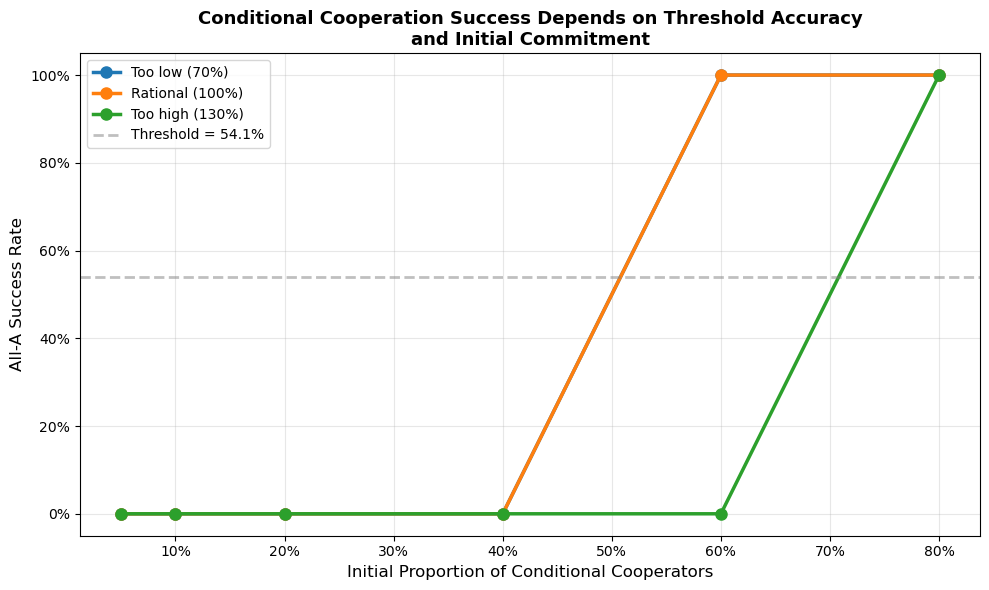


✓ Key findings:
  • Threshold must be set accurately for conditional cooperation to work
  • Requires sufficient initial proportion of C or A players
  • Even with optimal threshold, success requires high initial commitment


In [12]:
"""BLOCK 6 DEMONSTRATION: CONDITIONAL COOPERATION EFFECTS"""

print_section_header(
    "Conditional Cooperation in Interdependent Games",
    "Testing whether conditional cooperation can escape suboptimal equilibria"
)

# Test configuration: n=2 games, weak coupling
a_test = 0.5
c_test = 0.6
beta_test = 1.0

print(f"Test system: n=2 games, a={a_test}, c={c_test}, β={beta_test}")

# Compute rational threshold (assuming symmetric equilibrium with moderate coordination)
# For interdependent games, optimal threshold is harder to compute analytically
# Use empirical estimate based on independent game formula
alpha_estimate = a_test * 0.5 + c_test  # Rough estimate
rational_threshold = beta_test / (alpha_estimate + beta_test)
print(f"Estimated rational threshold: θ = {rational_threshold:.3f}")

# Test different threshold settings
threshold_configs = [
    {'multiplier': 0.7, 'label': 'Too low (70%)'},
    {'multiplier': 1.0, 'label': 'Rational (100%)'},
    {'multiplier': 1.3, 'label': 'Too high (130%)'}
]

# Test different initial proportions of C-players
c_proportion_tests = [0.05, 0.10, 0.20, 0.40, 0.60, 0.80]

print("\nTesting threshold accuracy and initial C proportion...")
print("="*80)

threshold_results = {}

for config in threshold_configs:
    threshold = config['multiplier'] * rational_threshold
    label = config['label']
    
    print(f"\n{label}: θ = {threshold:.3f}")
    print("-" * 60)
    
    results_by_c = {}
    
    for c_prop in c_proportion_tests:
        model_C = NGameWithConditionalCooperation(
            n_games=2,
            alpha_coupling=a_test,
            constant=c_test,
            beta=beta_test,
            within_correlation=0.0,
            threshold=threshold
        )
        
        # Test with varying initial C (and small A)
        results = model_C.measure_basins_with_C(
            x_A_range=(0, 0.05),
            x_C_range=(c_prop-0.05, c_prop+0.05),
            n_trials=150,  # Smaller for speed
            seed=RANDOM_SEED
        )
        
        results_by_c[c_prop] = results
        print(f"  C={c_prop:.0%}: All-A={results['All-A']:.1%}, "
              f"All-B={results['All-B']:.1%}, Mixed={results['Mixed']:.1%}")
    
    threshold_results[label] = results_by_c

# Visualize conditional cooperation effects
print("\nGenerating conditional cooperation visualization...")

fig, ax = plt.subplots(figsize=(10, 6))

for config in threshold_configs:
    label = config['label']
    results_by_c = threshold_results[label]
    
    c_vals = sorted(results_by_c.keys())
    all_a_success = [results_by_c[c]['All-A'] for c in c_vals]
    
    ax.plot(c_vals, all_a_success, marker='o', markersize=8,
            linewidth=2.5, label=label)

# Add threshold line
ax.axhline(rational_threshold, color='gray', linestyle='--', 
           linewidth=2, alpha=0.5, label=f'Threshold = {rational_threshold:.1%}')

ax.set_xlabel('Initial Proportion of Conditional Cooperators', fontsize=12)
ax.set_ylabel('All-A Success Rate', fontsize=12)
ax.set_title('Conditional Cooperation Success Depends on Threshold Accuracy\nand Initial Commitment', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

print("\n✓ Key findings:")
print("  • Threshold must be set accurately for conditional cooperation to work")
print("  • Requires sufficient initial proportion of C or A players")
print("  • Even with optimal threshold, success requires high initial commitment")


THE WEAK LINK PROBLEM
How heterogeneous game parameters create structural barriers to coordination

Demonstrating that conditional cooperation fails when some games have
parameters that prevent them from achieving α > 1 even with full support.

System: n=5 games (ring), a=0.4, β=1.0

Viability Analysis:

Scenario 1: All games viable (c = 0.8)
------------------------------------------------------------
  Maximum possible α = a·(1) + c = 0.4·(1) + 0.8 = 1.2000000000000002
  Is α > β? 1.2000000000000002 > 1.0: True
  → All games CAN prefer A over B with neighbor support ✓

Scenario 2: Weak links present (games 1,3 have c = 0.2)
------------------------------------------------------------
  Viable games (0, 2, 4):
    Maximum possible α = 0.4·(1) + 0.8 = 1.2000000000000002
    Can prefer A: True ✓
  Weak link games (1, 3):
    Maximum possible α = 0.4·(1) + 0.2 = 0.6000000000000001
    Can prefer A: False ✗
    → These games prefer B even with full neighbor coordination!

Testing Conditi

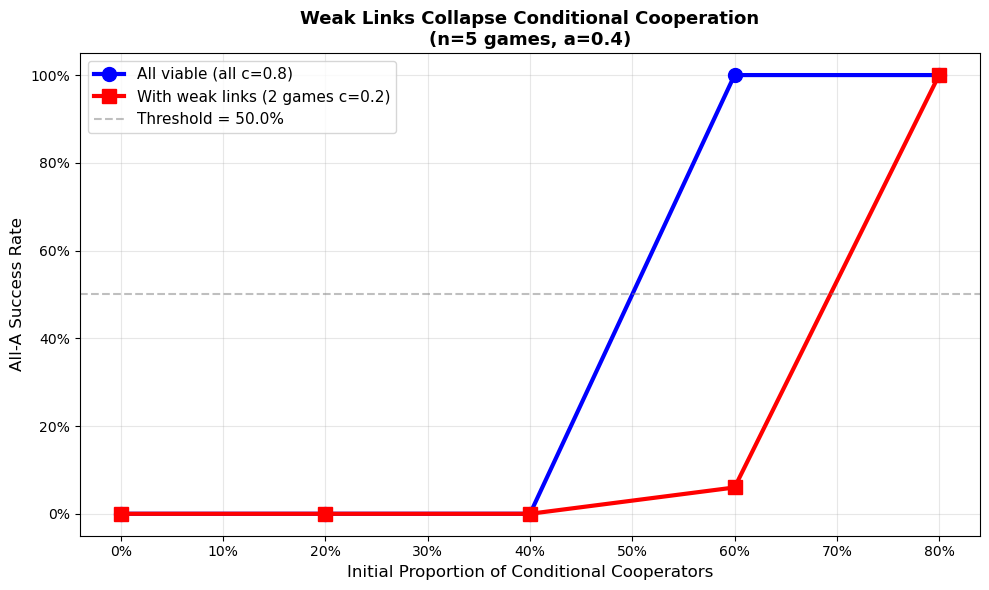


Generating trajectory comparison...


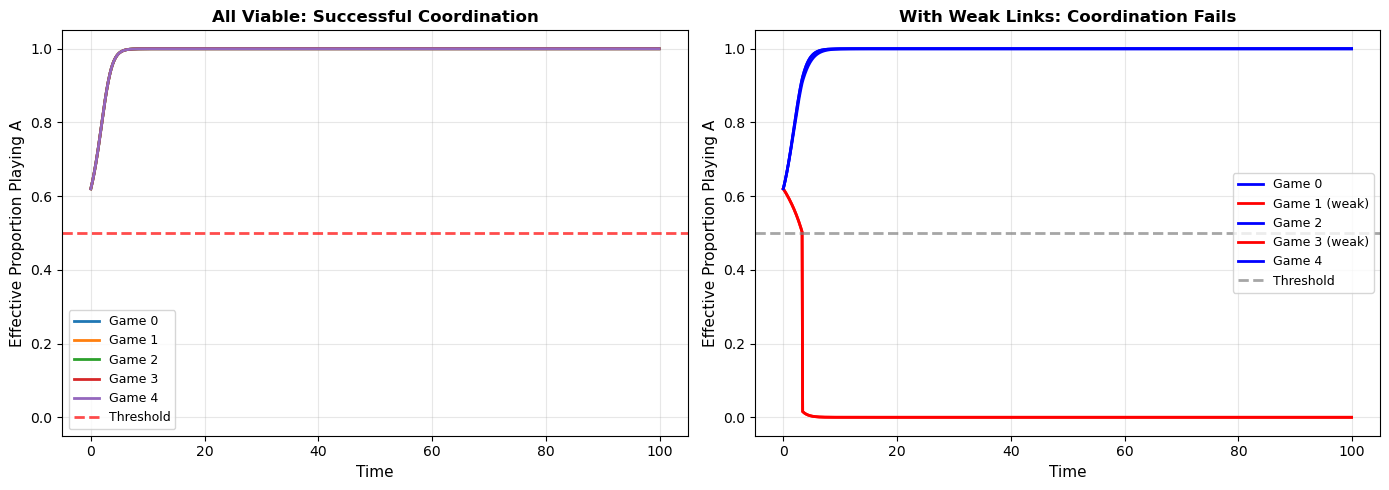


✓ Key findings:
  • When all games are viable (can achieve α > β), conditional cooperation succeeds
  • Weak link games (α < β even with full support) create structural barriers
  • Weak links prevent system-wide coordination regardless of initial commitment
  • The system is only as strong as its weakest link


In [13]:
"""BLOCK 7: WEAK LINK PROBLEM DEMONSTRATION"""

print_section_header(
    "The Weak Link Problem",
    "How heterogeneous game parameters create structural barriers to coordination"
)

print("Demonstrating that conditional cooperation fails when some games have")
print("parameters that prevent them from achieving α > 1 even with full support.")
print()

# Configuration: 5 games in a ring
n_games = 5
a_test = 0.4
beta_test = 1.0

# Scenario 1: All viable (all games have c = 0.8)
c_all_viable = 0.8

# Scenario 2: Weak links (games 1 and 3 have c = 0.2, others have c = 0.8)
c_with_weak_links = np.array([0.8, 0.2, 0.8, 0.2, 0.8])

print(f"System: n={n_games} games (ring), a={a_test}, β={beta_test}")
print()

# Analyze viability
print("Viability Analysis:")
print("="*80)

print("\nScenario 1: All games viable (c = 0.8)")
print("-" * 60)
max_alpha_viable = a_test * 1.0 + c_all_viable  # Max when both neighbors at x=1
print(f"  Maximum possible α = a·(1) + c = {a_test}·(1) + {c_all_viable} = {max_alpha_viable}")
print(f"  Is α > β? {max_alpha_viable} > {beta_test}: {max_alpha_viable > beta_test}")
print(f"  → All games CAN prefer A over B with neighbor support ✓")

print("\nScenario 2: Weak links present (games 1,3 have c = 0.2)")
print("-" * 60)
print("  Viable games (0, 2, 4):")
max_alpha_viable_high = a_test * 1.0 + 0.8
print(f"    Maximum possible α = {a_test}·(1) + 0.8 = {max_alpha_viable_high}")
print(f"    Can prefer A: {max_alpha_viable_high > beta_test} ✓")

print("  Weak link games (1, 3):")
max_alpha_weak = a_test * 1.0 + 0.2
print(f"    Maximum possible α = {a_test}·(1) + 0.2 = {max_alpha_weak}")
print(f"    Can prefer A: {max_alpha_weak > beta_test} ✗")
print(f"    → These games prefer B even with full neighbor coordination!")

# Test conditional cooperation in both scenarios
print("\n" + "="*80)
print("Testing Conditional Cooperation")
print("="*80)

# Compute thresholds (use rough estimate for interdependent case)
threshold_viable = beta_test / (1.0 + beta_test)  # Rough estimate
threshold_weak = np.array([threshold_viable] * n_games)

initial_c_levels = [0.0, 0.2, 0.4, 0.6, 0.8]
n_trials_weak = 150

print(f"\nUsing threshold estimate: θ ≈ {threshold_viable:.3f}")
print()

# Scenario 1: All viable
print("Scenario 1 Results (all games viable):")
print("-" * 60)

model_viable = NGameWithConditionalCooperation(
    n_games=n_games,
    alpha_coupling=a_test,
    constant=c_all_viable,
    beta=beta_test,
    within_correlation=0.0,
    threshold=threshold_viable
)

results_viable = {}
for c_init in initial_c_levels:
    results = model_viable.measure_basins_with_C(
        x_A_range=(0, 0.05),
        x_C_range=(max(0, c_init-0.05), min(1, c_init+0.05)),
        n_trials=n_trials_weak,
        seed=RANDOM_SEED
    )
    results_viable[c_init] = results
    print(f"  Initial C = {c_init:.0%}: All-A = {results['All-A']:.1%}")

# Scenario 2: Weak links
print("\nScenario 2 Results (weak links at games 1, 3):")
print("-" * 60)

# Need to create model with heterogeneous c values
# Extend the class to handle this, or create multiple simulations
# For simplicity, let's manually create the heterogeneous case

class NGameWithConditionalCooperationHeterogeneous(NGameWithConditionalCooperation):
    """Extension to handle heterogeneous constant values across games."""
    
    def __init__(self,
                 n_games: int,
                 alpha_coupling: float,
                 constant: np.ndarray,  # Now an array
                 beta: float = 1.0,
                 within_correlation: float = 0.0,
                 network_type: str = 'ring',
                 threshold: float | np.ndarray = 0.5):
        
        # Store heterogeneous constants before calling parent __init__
        if len(constant) != n_games:
            raise ValueError(f"Constant array must have length {n_games}")
        self.c_array = np.array(constant)
        
        # Call parent with dummy constant (will override compute_alpha)
        NGameCoordinationSystem.__init__(
            self, n_games, alpha_coupling, 0.0, beta, 
            within_correlation, network_type
        )
        
        # Handle threshold parameter
        if np.isscalar(threshold):
            self.theta = np.full(n_games, threshold)
        else:
            if len(threshold) != n_games:
                raise ValueError(f"Threshold array must have length {n_games}")
            self.theta = np.array(threshold)
    
    def compute_alpha(self, x: np.ndarray, game_idx: int) -> float:
        """Override to use heterogeneous constants."""
        if self.n == 1:
            return self.c_array[game_idx]
        elif self.n == 2:
            other_idx = 1 - game_idx
            return self.a * x[other_idx] + self.c_array[game_idx]
        else:
            left_neighbor = x[(game_idx - 1) % self.n]
            right_neighbor = x[(game_idx + 1) % self.n]
            return self.a * (left_neighbor + right_neighbor) / 2 + self.c_array[game_idx]

model_weak = NGameWithConditionalCooperationHeterogeneous(
    n_games=n_games,
    alpha_coupling=a_test,
    constant=c_with_weak_links,
    beta=beta_test,
    within_correlation=0.0,
    threshold=threshold_viable
)

results_weak = {}
for c_init in initial_c_levels:
    results = model_weak.measure_basins_with_C(
        x_A_range=(0, 0.05),
        x_C_range=(max(0, c_init-0.05), min(1, c_init+0.05)),
        n_trials=n_trials_weak,
        seed=RANDOM_SEED
    )
    results_weak[c_init] = results
    print(f"  Initial C = {c_init:.0%}: All-A = {results['All-A']:.1%}")

# Visualize the weak link problem
print("\nGenerating weak link comparison visualization...")

fig, ax = plt.subplots(figsize=(10, 6))

c_vals = sorted(results_viable.keys())

# Plot both scenarios
all_a_viable = [results_viable[c]['All-A'] for c in c_vals]
all_a_weak = [results_weak[c]['All-A'] for c in c_vals]

ax.plot(c_vals, all_a_viable, marker='o', markersize=10, linewidth=3,
        label='All viable (all c=0.8)', color='blue')
ax.plot(c_vals, all_a_weak, marker='s', markersize=10, linewidth=3,
        label='With weak links (2 games c=0.2)', color='red')

# Add threshold reference
ax.axhline(threshold_viable, color='gray', linestyle='--', 
           linewidth=1.5, alpha=0.5, label=f'Threshold = {threshold_viable:.1%}')

ax.set_xlabel('Initial Proportion of Conditional Cooperators', fontsize=12)
ax.set_ylabel('All-A Success Rate', fontsize=12)
ax.set_title('Weak Links Collapse Conditional Cooperation\n' + 
             f'(n={n_games} games, a={a_test})', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

# Detailed trajectory comparison
print("\nGenerating trajectory comparison...")

# Show a specific case: 60% initial C-players
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

test_c_init = 0.6
test_a_init = 0.02

x_A0 = np.full(n_games, test_a_init)
x_C0 = np.full(n_games, test_c_init)

# Scenario 1: All viable
t1, x_A1, x_C1 = model_viable.simulate_with_C(x_A0, x_C0, T=100)
x_eff1 = np.array([model_viable.compute_effective_x(x_A1[i], x_C1[i]) 
                    for i in range(len(t1))])

ax1 = axes[0]
for i in range(n_games):
    ax1.plot(t1, x_eff1[:, i], linewidth=2, label=f'Game {i}')
ax1.axhline(threshold_viable, color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label='Threshold')
ax1.set_xlabel('Time', fontsize=11)
ax1.set_ylabel('Effective Proportion Playing A', fontsize=11)
ax1.set_title('All Viable: Successful Coordination', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# Scenario 2: Weak links
t2, x_A2, x_C2 = model_weak.simulate_with_C(x_A0, x_C0, T=100)
x_eff2 = np.array([model_weak.compute_effective_x(x_A2[i], x_C2[i]) 
                    for i in range(len(t2))])

ax2 = axes[1]
colors = ['blue', 'red', 'blue', 'red', 'blue']  # Highlight weak links
for i in range(n_games):
    label = f'Game {i} (weak)' if c_with_weak_links[i] == 0.2 else f'Game {i}'
    ax2.plot(t2, x_eff2[:, i], linewidth=2, label=label, color=colors[i])
ax2.axhline(threshold_viable, color='gray', linestyle='--', 
            linewidth=2, alpha=0.7, label='Threshold')
ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('Effective Proportion Playing A', fontsize=11)
ax2.set_title('With Weak Links: Coordination Fails', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("\n✓ Key findings:")
print("  • When all games are viable (can achieve α > β), conditional cooperation succeeds")
print("  • Weak link games (α < β even with full support) create structural barriers")
print("  • Weak links prevent system-wide coordination regardless of initial commitment")
print("  • The system is only as strong as its weakest link")


SCALE EFFECTS: HOW SYSTEM SIZE AFFECTS COORDINATION
Testing how viability of optimal coordination changes as n increases

Demonstrating that coordination becomes increasingly difficult as the
number of interdependent games grows, even with favorable parameters.

Testing system sizes: n = [2, 3, 4, 5, 6, 8, 10]
Trials per configuration: 5,000


Weak coupling, high baseline: a=0.5, c=0.6
  n= 2 games... All-A: 24.2%, All-B: 35.9%, Frag: 39.9%, Mixed:  0.0%
  n= 3 games... All-A: 12.2%, All-B: 21.5%, Frag: 66.3%, Mixed:  0.0%
  n= 4 games... All-A:  6.2%, All-B: 13.0%, Frag: 80.8%, Mixed:  0.0%
  n= 5 games... All-A:  3.4%, All-B:  7.9%, Frag: 88.8%, Mixed:  0.0%
  n= 6 games... All-A:  1.6%, All-B:  4.2%, Frag: 94.2%, Mixed:  0.0%
  n= 8 games... All-A:  0.4%, All-B:  1.1%, Frag: 98.4%, Mixed:  0.0%
  n=10 games... All-A:  0.0%, All-B:  0.3%, Frag: 99.7%, Mixed:  0.0%

Moderate coupling, moderate baseline: a=1.0, c=0.3
  n= 2 games... All-A: 26.1%, All-B: 47.8%, Frag: 26.1%, Mixed:  0.0

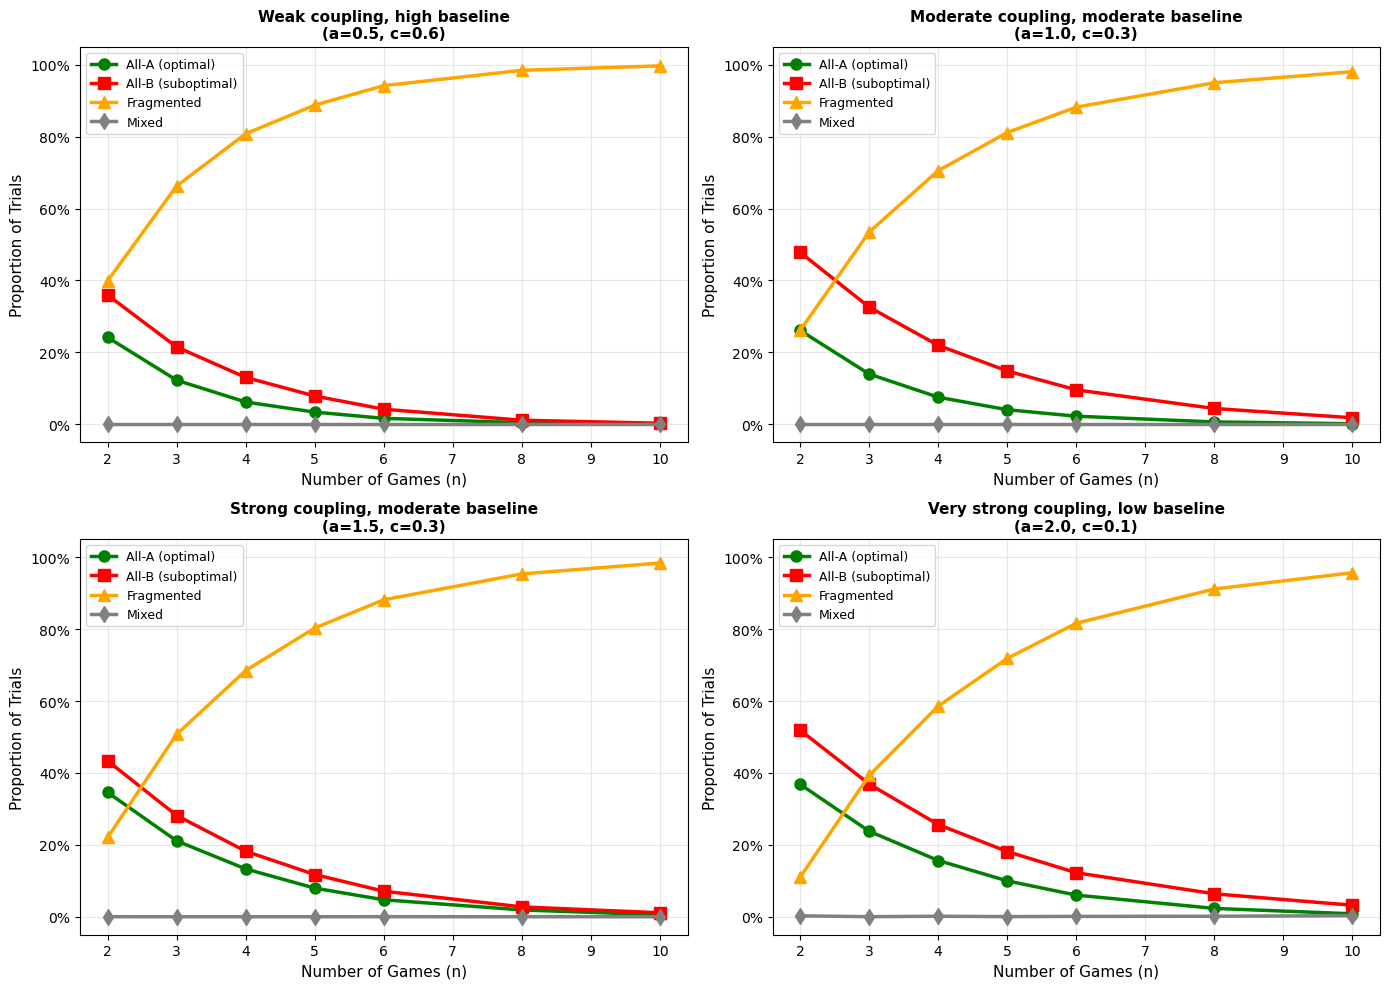


Generating All-A success comparison across parameter regimes...


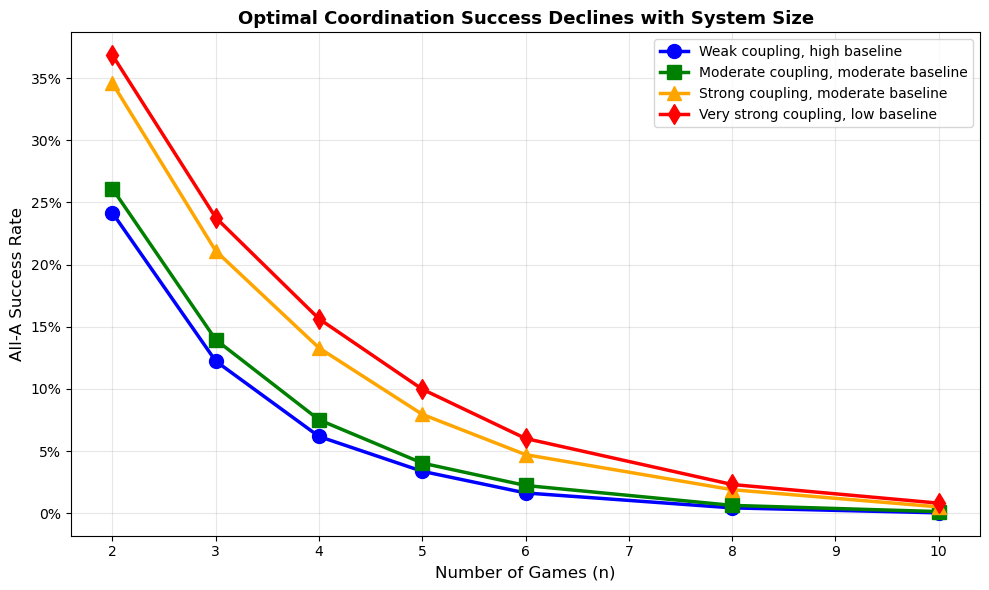


Decay Analysis:

Weak coupling, high baseline:
  n=2:  All-A = 24.2%
  n=10: All-A = 0.0%
  Absolute decline: 24.1%
  Relative decline: 99.8%

Moderate coupling, moderate baseline:
  n=2:  All-A = 26.1%
  n=10: All-A = 0.1%
  Absolute decline: 26.0%
  Relative decline: 99.5%

Strong coupling, moderate baseline:
  n=2:  All-A = 34.6%
  n=10: All-A = 0.5%
  Absolute decline: 34.1%
  Relative decline: 98.5%

Very strong coupling, low baseline:
  n=2:  All-A = 36.8%
  n=10: All-A = 0.8%
  Absolute decline: 36.0%
  Relative decline: 97.8%

Generating parameter space heatmap...

Computing heatmap for n=2...
  c=0.00... done
  c=0.07... done
  c=0.14... done
  c=0.21... done
  c=0.29... done
  c=0.36... done
  c=0.43... done
  c=0.50... done
  c=0.57... done
  c=0.64... done
  c=0.71... done
  c=0.79... done
  c=0.86... done
  c=0.93... done
  c=1.00... done

Computing heatmap for n=10...
  c=0.00... done
  c=0.07... done
  c=0.14... done
  c=0.21... done
  c=0.29... done
  c=0.36... done
  

In [ ]:
"""BLOCK 8: SCALE EFFECTS - SYSTEM SIZE"""

print_section_header(
    "Scale Effects: How System Size Affects Coordination",
    "Testing how viability of optimal coordination changes as n increases"
)

print("Demonstrating that coordination becomes increasingly difficult as the")
print("number of interdependent games grows, even with favorable parameters.")
print()

# Test different parameter regimes
scale_configs = [
    {'a': 0.5, 'c': 0.6, 'label': 'Weak coupling, high baseline'},
    {'a': 1.0, 'c': 0.3, 'label': 'Moderate coupling, moderate baseline'},
    {'a': 1.5, 'c': 0.3, 'label': 'Strong coupling, moderate baseline'},
    {'a': 2.0, 'c': 0.1, 'label': 'Very strong coupling, low baseline'}
]

n_values = [2, 3, 4, 5, 6, 8, 10]
n_trials_scale = 5000  # Balance between accuracy and computation time

print(f"Testing system sizes: n = {n_values}")
print(f"Trials per configuration: {n_trials_scale:,}")
print()

scale_results = {}

for config in scale_configs:
    print(f"\n{config['label']}: a={config['a']}, c={config['c']}")
    print("="*80)
    
    results_by_n = {}
    
    for n in n_values:
        print(f"  n={n:2d} games...", end='', flush=True)
        
        model = NGameCoordinationSystem(
            n_games=n,
            alpha_coupling=config['a'],
            constant=config['c'],
            beta=1.0,
            within_correlation=0.0
        )
        
        results = model.measure_basins(n_trials=n_trials_scale, seed=RANDOM_SEED)
        results_by_n[n] = results
        
        print(f" All-A: {results['All-A']:5.1%}, "
              f"All-B: {results['All-B']:5.1%}, "
              f"Frag: {results['Fragmented']:5.1%}, "
              f"Mixed: {results['Mixed']:5.1%}")
    
    scale_results[config['label']] = results_by_n

# Visualize scale effects
print("\nGenerating scale effects visualization...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, config in enumerate(scale_configs):
    ax = axes[idx]
    label = config['label']
    results_by_n = scale_results[label]
    
    n_vals = sorted(results_by_n.keys())
    all_a = [results_by_n[n]['All-A'] for n in n_vals]
    all_b = [results_by_n[n]['All-B'] for n in n_vals]
    fragmented = [results_by_n[n]['Fragmented'] for n in n_vals]
    mixed = [results_by_n[n]['Mixed'] for n in n_vals]
    
    # Plot all outcomes
    ax.plot(n_vals, all_a, marker='o', markersize=8, linewidth=2.5,
            label='All-A (optimal)', color='green')
    ax.plot(n_vals, all_b, marker='s', markersize=8, linewidth=2.5,
            label='All-B (suboptimal)', color='red')
    ax.plot(n_vals, fragmented, marker='^', markersize=8, linewidth=2.5,
            label='Fragmented', color='orange')
    ax.plot(n_vals, mixed, marker='d', markersize=8, linewidth=2.5,
            label='Mixed', color='gray')
    
    ax.set_xlabel('Number of Games (n)', fontsize=11)
    ax.set_ylabel('Proportion of Trials', fontsize=11)
    ax.set_title(f'{label}\n(a={config["a"]}, c={config["c"]})', 
                fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

# Create a focused comparison plot for All-A success
print("\nGenerating All-A success comparison across parameter regimes...")

fig, ax = plt.subplots(figsize=(10, 6))

markers = ['o', 's', '^', 'd']
colors = ['blue', 'green', 'orange', 'red']

for idx, config in enumerate(scale_configs):
    label = config['label']
    results_by_n = scale_results[label]
    
    n_vals = sorted(results_by_n.keys())
    all_a = [results_by_n[n]['All-A'] for n in n_vals]
    
    ax.plot(n_vals, all_a, marker=markers[idx], markersize=10, 
            linewidth=2.5, label=label, color=colors[idx])

ax.set_xlabel('Number of Games (n)', fontsize=12)
ax.set_ylabel('All-A Success Rate', fontsize=12)
ax.set_title('Optimal Coordination Success Declines with System Size', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

# Statistical analysis: compute decay rates
print("\nDecay Analysis:")
print("="*80)

for config in scale_configs:
    label = config['label']
    results_by_n = scale_results[label]
    
    n_vals = sorted(results_by_n.keys())
    all_a = [results_by_n[n]['All-A'] for n in n_vals]
    
    # Compute relative decline from n=2 to n=10
    if 2 in n_vals and 10 in n_vals:
        initial = results_by_n[2]['All-A']
        final = results_by_n[10]['All-A']
        absolute_decline = initial - final
        relative_decline = absolute_decline / initial if initial > 0 else 0
        
        print(f"\n{label}:")
        print(f"  n=2:  All-A = {initial:.1%}")
        print(f"  n=10: All-A = {final:.1%}")
        print(f"  Absolute decline: {absolute_decline:.1%}")
        print(f"  Relative decline: {relative_decline:.1%}")

# Create heatmap of success rates across n and parameter space
print("\nGenerating parameter space heatmap...")

# Focus on varying a and c for n=2 and n=10
a_range = np.linspace(0.0, 2.0, 15)
c_range = np.linspace(0.0, 1.0, 15)
n_test_values = [2, 10]

n_trials_heatmap = 1000  # Reduced for computation time

heatmap_data = {}

for n_test in n_test_values:
    print(f"\nComputing heatmap for n={n_test}...")
    success_grid = np.zeros((len(c_range), len(a_range)))
    
    for i, c_val in enumerate(c_range):
        print(f"  c={c_val:.2f}...", end='', flush=True)
        for j, a_val in enumerate(a_range):
            model = NGameCoordinationSystem(
                n_games=n_test,
                alpha_coupling=a_val,
                constant=c_val,
                beta=1.0,
                within_correlation=0.0
            )
            
            results = model.measure_basins(n_trials=n_trials_heatmap, seed=RANDOM_SEED)
            success_grid[i, j] = results['All-A']
        print(" done")
    
    heatmap_data[n_test] = success_grid

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, n_test in enumerate(n_test_values):
    ax = axes[idx]
    
    im = ax.contourf(a_range, c_range, heatmap_data[n_test], 
                     levels=20, cmap='RdYlGn', vmin=0, vmax=1)
    
    # Add contour lines
    contours = ax.contour(a_range, c_range, heatmap_data[n_test],
                         levels=[0.25, 0.5, 0.75], colors='black', 
                         linewidths=1.5, alpha=0.4)
    ax.clabel(contours, inline=True, fontsize=9, fmt='%.0f%%')
    
    ax.set_xlabel('Interdependence Strength (a)', fontsize=11)
    ax.set_ylabel('Constant Value (c)', fontsize=11)
    ax.set_title(f'All-A Success Rate: n={n_test} games', 
                fontsize=12, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Success Rate', fontsize=10)
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY: SCALE EFFECTS")
print("="*80)

print("\nKey Findings:")
print("  1. Optimal coordination success decreases as system size increases")
print("  2. The decline is steepest for weak-moderate coupling regimes")
print("  3. Even strong coupling shows degradation at larger scales")
print("  4. Fragmentation increases with system size in moderate coupling")
print("  5. Parameter space for reliable coordination shrinks dramatically")

print("\nComparison across regimes (n=2 vs n=10):")
for config in scale_configs:
    label = config['label']
    results_by_n = scale_results[label]
    if 2 in results_by_n and 10 in results_by_n:
        decline = results_by_n[2]['All-A'] - results_by_n[10]['All-A']
        print(f"  {label:40s}: -{decline:5.1%}")

print("Scale effects tested: larger systems face structural barriers")


CORRELATION EFFECTS ACROSS SYSTEM SIZES
How within-game correlation mechanisms interact with system scale

Testing whether correlation's effectiveness (or harm) depends on system size.
Does correlation help more or less as the number of interdependent games grows?

System sizes: n = [2, 4, 6, 8, 10]
Correlation levels: r = [0.0, 0.3, 0.6, 0.9]
Trials per configuration: 2,000


Weak coupling, high baseline: a=0.5, c=0.6

  n=2 games:
    r=0.0... All-A: 25.4%, Frag: 40.1%
    r=0.3... All-A: 25.7%, Frag: 29.3%
    r=0.6... All-A: 25.5%, Frag:  4.7%
    r=0.9... All-A: 18.4%, Frag:  0.0%

  n=4 games:
    r=0.0... All-A:  5.7%, Frag: 82.2%
    r=0.3... All-A:  5.7%, Frag: 73.8%
    r=0.6... All-A:  5.8%, Frag: 39.0%
    r=0.9... All-A:  4.5%, Frag:  0.1%

  n=6 games:
    r=0.0... All-A:  1.0%, Frag: 94.8%
    r=0.3... All-A:  1.1%, Frag: 89.7%
    r=0.6... All-A:  1.1%, Frag: 56.5%
    r=0.9... All-A:  0.7%, Frag:  2.4%

  n=8 games:
    r=0.0... All-A:  0.2%, Frag: 98.5%
    r=0.3... 

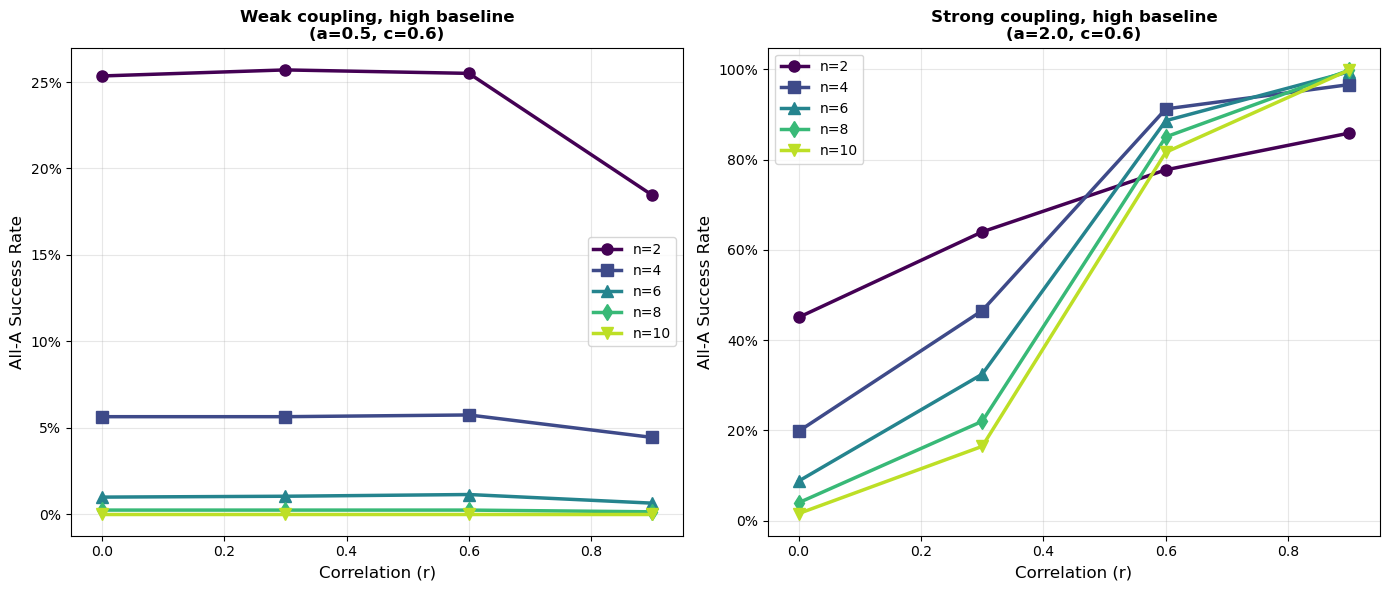


Generating fragmentation reduction visualization...


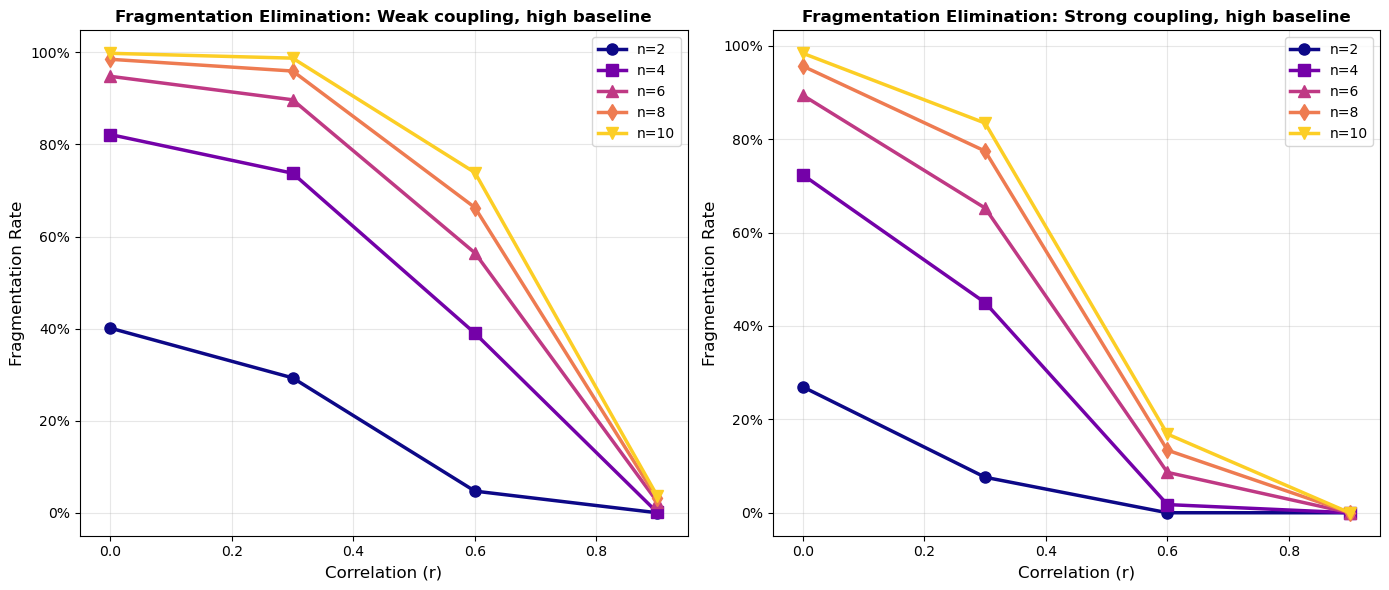


Generating correlation-scale heatmaps...


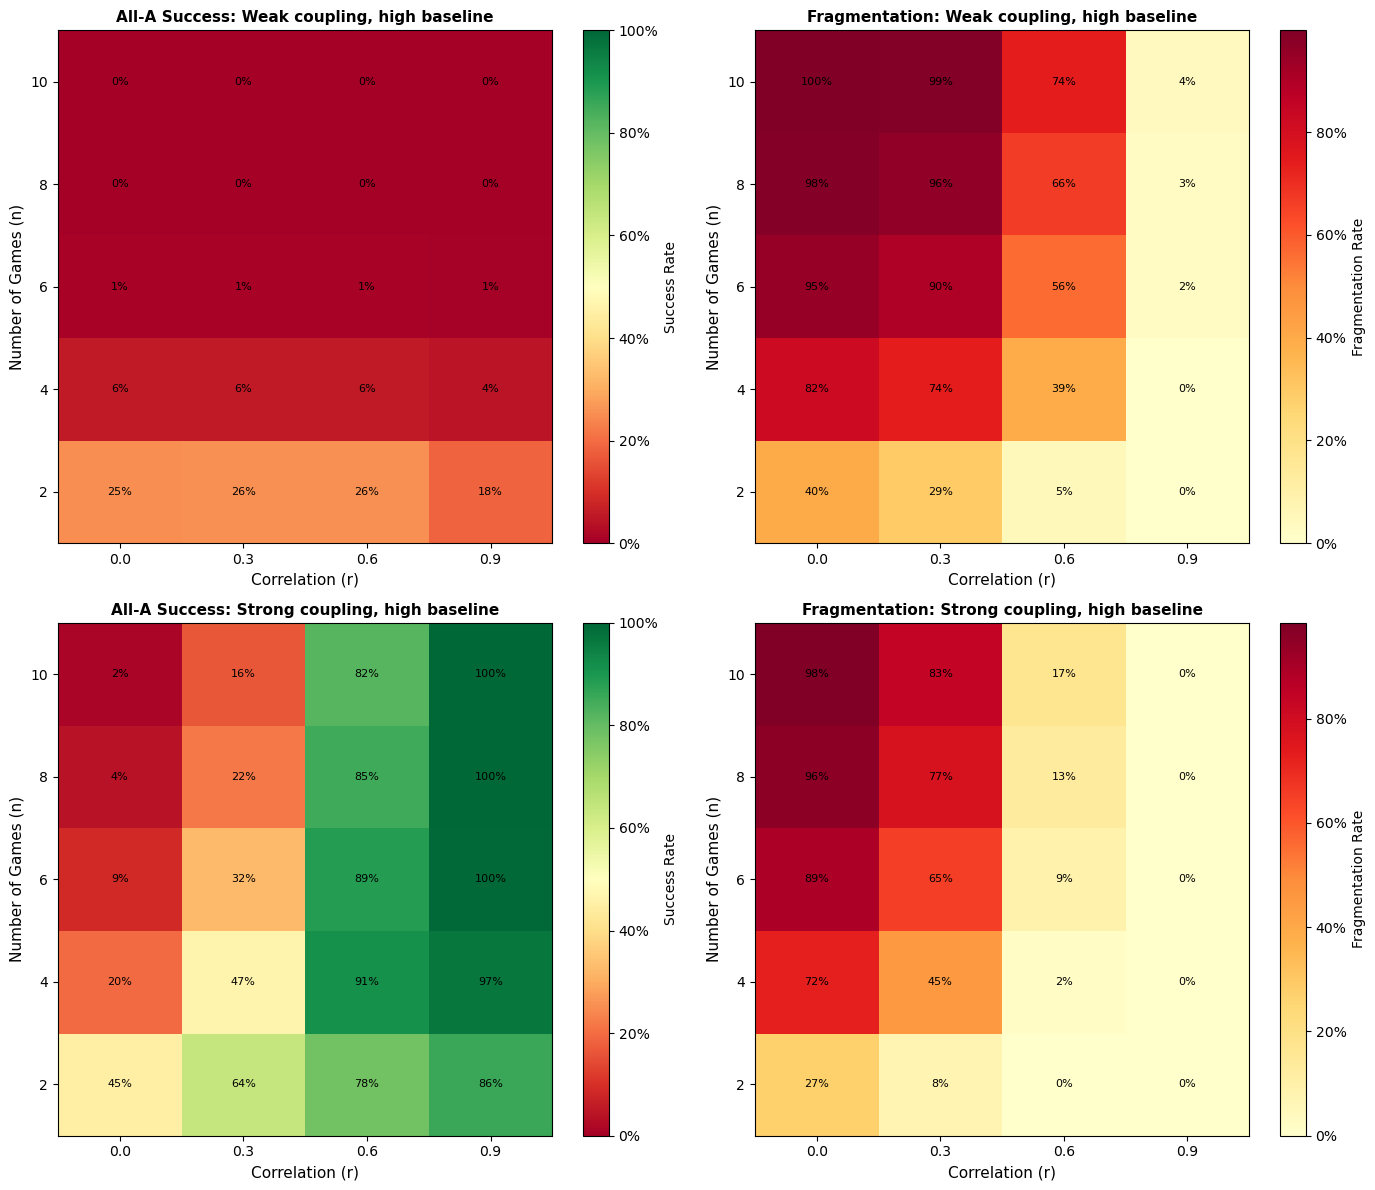


CORRELATION EFFECTIVENESS ANALYSIS

Weak coupling, high baseline:
------------------------------------------------------------
   n |    Δ All-A (r=0→0.9) |     Δ Frag (r=0→0.9)
------------------------------------------------------------
   2 |              -6.9% |             -40.1%
   4 |              -1.2% |             -82.0%
   6 |              -0.4% |             -92.4%
   8 |              -0.1% |             -95.4%
  10 |              +0.0% |             -96.1%

Strong coupling, high baseline:
------------------------------------------------------------
   n |    Δ All-A (r=0→0.9) |     Δ Frag (r=0→0.9)
------------------------------------------------------------
   2 |             +40.8% |             -27.0%
   4 |             +76.8% |             -72.4%
   6 |             +90.8% |             -89.4%
   8 |             +95.9% |             -95.6%
  10 |             +98.4% |             -98.4%

Generating correlation effect magnitude comparison...


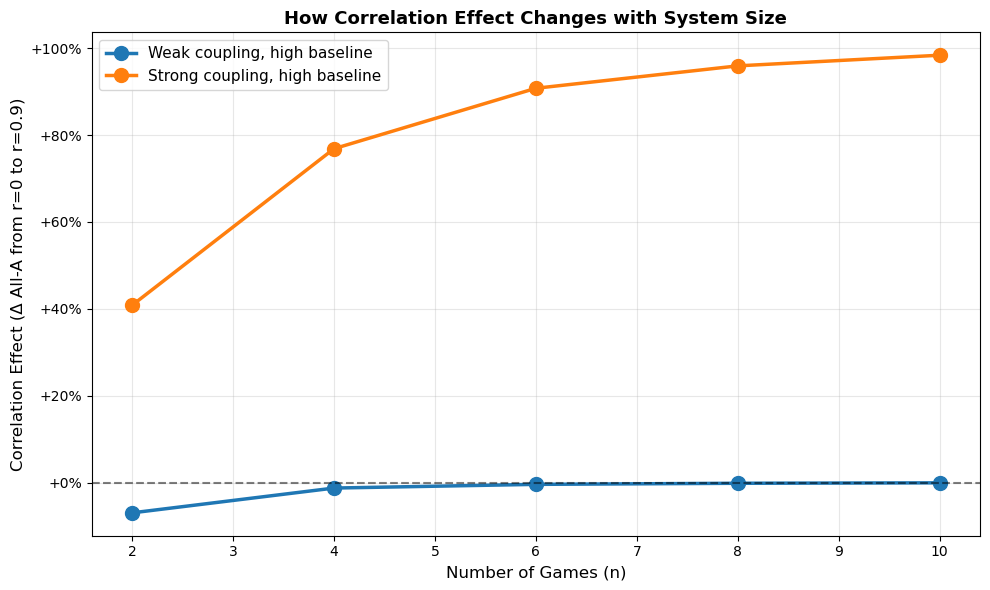


SUMMARY: CORRELATION EFFECTS AT SCALE

Key Findings:
  1. WEAK COUPLING: Correlation reduces All-A success at all scales
     • Effect becomes more negative as n increases
     • Larger systems amplify correlation's harm

  2. STRONG COUPLING: Correlation increases All-A success at all scales
     • Effect magnitude varies with n
     • Benefit persists but doesn't fully compensate for scale effects

  3. FRAGMENTATION: Correlation eliminates fragmentation across all scales
     • Consistent reduction to near-zero regardless of n
     • This holds for both weak and strong coupling

  4. INTERACTION EFFECTS:
     • Weak coupling + correlation + large n = catastrophic coordination failure
     • Strong coupling + correlation + large n = modest improvement but still challenging
     • Correlation doesn't solve the fundamental scale problem

✓ Correlation at scale demonstrated: mechanism effectiveness depends on both
  coupling strength AND system size, with complex interactions


In [15]:
"""BLOCK 9: CORRELATION EFFECTS AT SCALE"""

print_section_header(
    "Correlation Effects Across System Sizes",
    "How within-game correlation mechanisms interact with system scale"
)

print("Testing whether correlation's effectiveness (or harm) depends on system size.")
print("Does correlation help more or less as the number of interdependent games grows?")
print()

# Test configurations: focus on weak and strong coupling
correlation_scale_configs = [
    {'a': 0.5, 'c': 0.6, 'label': 'Weak coupling, high baseline'},
    {'a': 2.0, 'c': 0.6, 'label': 'Strong coupling, high baseline'}
]

n_values_correlation = [2, 4, 6, 8, 10]
r_values = [0.0, 0.3, 0.6, 0.9]
n_trials_cor_scale = 2000  # Balance accuracy and computation time

print(f"System sizes: n = {n_values_correlation}")
print(f"Correlation levels: r = {r_values}")
print(f"Trials per configuration: {n_trials_cor_scale:,}")
print()

correlation_scale_results = {}

for config in correlation_scale_configs:
    print(f"\n{config['label']}: a={config['a']}, c={config['c']}")
    print("="*80)
    
    results_by_n_and_r = {}
    
    for n in n_values_correlation:
        print(f"\n  n={n} games:")
        results_by_r = {}
        
        for r in r_values:
            print(f"    r={r:.1f}...", end='', flush=True)
            
            model = NGameCoordinationSystem(
                n_games=n,
                alpha_coupling=config['a'],
                constant=config['c'],
                beta=1.0,
                within_correlation=r
            )
            
            results = model.measure_basins(n_trials=n_trials_cor_scale, seed=RANDOM_SEED)
            results_by_r[r] = results
            
            print(f" All-A: {results['All-A']:5.1%}, Frag: {results['Fragmented']:5.1%}")
        
        results_by_n_and_r[n] = results_by_r
    
    correlation_scale_results[config['label']] = results_by_n_and_r

# Visualize: All-A success across n and r for each regime
print("\nGenerating correlation-scale interaction visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, config in enumerate(correlation_scale_configs):
    ax = axes[idx]
    label = config['label']
    results = correlation_scale_results[label]
    
    # Plot lines for each system size
    markers = ['o', 's', '^', 'd', 'v']
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(n_values_correlation)))
    
    for n_idx, n in enumerate(n_values_correlation):
        r_vals = sorted(results[n].keys())
        all_a = [results[n][r]['All-A'] for r in r_vals]
        
        ax.plot(r_vals, all_a, marker=markers[n_idx], markersize=8,
                linewidth=2.5, label=f'n={n}', color=colors[n_idx])
    
    ax.set_xlabel('Correlation (r)', fontsize=12)
    ax.set_ylabel('All-A Success Rate', fontsize=12)
    ax.set_title(f'{label}\n(a={config["a"]}, c={config["c"]})', 
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xlim(-0.05, 0.95)

plt.tight_layout()
plt.show()

# Visualize: Fragmentation reduction across n and r
print("\nGenerating fragmentation reduction visualization...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, config in enumerate(correlation_scale_configs):
    ax = axes[idx]
    label = config['label']
    results = correlation_scale_results[label]
    
    colors = plt.cm.plasma(np.linspace(0, 0.9, len(n_values_correlation)))
    
    for n_idx, n in enumerate(n_values_correlation):
        r_vals = sorted(results[n].keys())
        fragmented = [results[n][r]['Fragmented'] for r in r_vals]
        
        ax.plot(r_vals, fragmented, marker=markers[n_idx], markersize=8,
                linewidth=2.5, label=f'n={n}', color=colors[n_idx])
    
    ax.set_xlabel('Correlation (r)', fontsize=12)
    ax.set_ylabel('Fragmentation Rate', fontsize=12)
    ax.set_title(f'Fragmentation Elimination: {label}', 
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xlim(-0.05, 0.95)

plt.tight_layout()
plt.show()

# Create heatmaps showing correlation effect at different scales
print("\nGenerating correlation-scale heatmaps...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for config_idx, config in enumerate(correlation_scale_configs):
    label = config['label']
    results = correlation_scale_results[label]
    
    # Create grids for All-A and Fragmentation
    n_vals = sorted(results.keys())
    r_vals = sorted(results[n_vals[0]].keys())
    
    all_a_grid = np.zeros((len(n_vals), len(r_vals)))
    frag_grid = np.zeros((len(n_vals), len(r_vals)))
    
    for i, n in enumerate(n_vals):
        for j, r in enumerate(r_vals):
            all_a_grid[i, j] = results[n][r]['All-A']
            frag_grid[i, j] = results[n][r]['Fragmented']
    
    # Plot All-A heatmap
    ax_all_a = axes[config_idx, 0]
    im1 = ax_all_a.imshow(all_a_grid, aspect='auto', cmap='RdYlGn',
                          vmin=0, vmax=1, origin='lower')
    ax_all_a.set_xticks(range(len(r_vals)))
    ax_all_a.set_xticklabels([f'{r:.1f}' for r in r_vals])
    ax_all_a.set_yticks(range(len(n_vals)))
    ax_all_a.set_yticklabels([f'{n}' for n in n_vals])
    ax_all_a.set_xlabel('Correlation (r)', fontsize=11)
    ax_all_a.set_ylabel('Number of Games (n)', fontsize=11)
    ax_all_a.set_title(f'All-A Success: {label}', fontsize=11, fontweight='bold')
    
    # Add text annotations
    for i in range(len(n_vals)):
        for j in range(len(r_vals)):
            text = ax_all_a.text(j, i, f'{all_a_grid[i, j]:.0%}',
                               ha="center", va="center", color="black", fontsize=8)
    
    cbar1 = plt.colorbar(im1, ax=ax_all_a)
    cbar1.set_label('Success Rate', fontsize=10)
    cbar1.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    
    # Plot Fragmentation heatmap
    ax_frag = axes[config_idx, 1]
    im2 = ax_frag.imshow(frag_grid, aspect='auto', cmap='YlOrRd',
                        vmin=0, vmax=np.max(frag_grid), origin='lower')
    ax_frag.set_xticks(range(len(r_vals)))
    ax_frag.set_xticklabels([f'{r:.1f}' for r in r_vals])
    ax_frag.set_yticks(range(len(n_vals)))
    ax_frag.set_yticklabels([f'{n}' for n in n_vals])
    ax_frag.set_xlabel('Correlation (r)', fontsize=11)
    ax_frag.set_ylabel('Number of Games (n)', fontsize=11)
    ax_frag.set_title(f'Fragmentation: {label}', fontsize=11, fontweight='bold')
    
    # Add text annotations
    for i in range(len(n_vals)):
        for j in range(len(r_vals)):
            text = ax_frag.text(j, i, f'{frag_grid[i, j]:.0%}',
                              ha="center", va="center", color="black", fontsize=8)
    
    cbar2 = plt.colorbar(im2, ax=ax_frag)
    cbar2.set_label('Fragmentation Rate', fontsize=10)
    cbar2.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

# Compute correlation effectiveness at different scales
print("\n" + "="*80)
print("CORRELATION EFFECTIVENESS ANALYSIS")
print("="*80)

for config in correlation_scale_configs:
    label = config['label']
    results = correlation_scale_results[label]
    
    print(f"\n{label}:")
    print("-" * 60)
    print(f"{'n':>4} | {'Δ All-A (r=0→0.9)':>20} | {'Δ Frag (r=0→0.9)':>20}")
    print("-" * 60)
    
    for n in n_values_correlation:
        baseline = results[n][0.0]['All-A']
        high_corr = results[n][0.9]['All-A']
        delta_all_a = high_corr - baseline
        
        baseline_frag = results[n][0.0]['Fragmented']
        high_corr_frag = results[n][0.9]['Fragmented']
        delta_frag = high_corr_frag - baseline_frag
        
        print(f"{n:>4} | {delta_all_a:>+18.1%} | {delta_frag:>+18.1%}")

# Create summary comparison: correlation effect magnitude vs scale
print("\nGenerating correlation effect magnitude comparison...")

fig, ax = plt.subplots(figsize=(10, 6))

for config in correlation_scale_configs:
    label = config['label']
    results = correlation_scale_results[label]
    
    n_vals = sorted(results.keys())
    correlation_effects = []
    
    for n in n_vals:
        baseline = results[n][0.0]['All-A']
        high_corr = results[n][0.9]['All-A']
        effect = high_corr - baseline
        correlation_effects.append(effect)
    
    ax.plot(n_vals, correlation_effects, marker='o', markersize=10,
            linewidth=2.5, label=label)

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Number of Games (n)', fontsize=12)
ax.set_ylabel('Correlation Effect (Δ All-A from r=0 to r=0.9)', fontsize=12)
ax.set_title('How Correlation Effect Changes with System Size', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:+.0%}'))

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "="*80)
print("SUMMARY: CORRELATION EFFECTS AT SCALE")
print("="*80)

print("\nKey Findings:")
print("  1. WEAK COUPLING: Correlation reduces All-A success at all scales")
print("     • Effect becomes more negative as n increases")
print("     • Larger systems amplify correlation's harm")

print("\n  2. STRONG COUPLING: Correlation increases All-A success at all scales")
print("     • Effect magnitude varies with n")
print("     • Benefit persists but doesn't fully compensate for scale effects")

print("\n  3. FRAGMENTATION: Correlation eliminates fragmentation across all scales")
print("     • Consistent reduction to near-zero regardless of n")
print("     • This holds for both weak and strong coupling")

print("\n  4. INTERACTION EFFECTS:")
print("     • Weak coupling + correlation + large n = catastrophic coordination failure")
print("     • Strong coupling + correlation + large n = modest improvement but still challenging")
print("     • Correlation doesn't solve the fundamental scale problem")

print(" Correlation at scale results: mechanism effectiveness depends on both")
print("  coupling strength and system size, with complex interactions")


UTILITY ANALYSIS: EVALUATING WELFARE OF COORDINATION OUTCOMES
Testing whether partial coordination delivers sufficient welfare gains

Objection: Maybe we're too focused on all-A optimality. Perhaps partial
coordination (fragmented outcomes) still delivers high utility compared to all-B.

We'll test this claim, using all-B as the baseline.

UTILITY COMPARISON: Outcome Types
System: n=5 games, a=1.0, c=0.3, β=1.0

Benchmark Utilities:
  All-A: 6.500 (average per game: 1.300)
  All-B: 5.000 (average per game: 1.000)
  Potential gain (All-A over All-B): 1.500

Sampling outcomes and computing utilities...
------------------------------------------------------------
Outcome Type    Count    Avg Utility     Utility Achieved    
All-A           39       6.500           100.0%              
Fragmented      798      4.564           -29.1%              
Mixed           0        N/A             N/A                 
All-B           163      5.000           0.0%                

Generating utility 

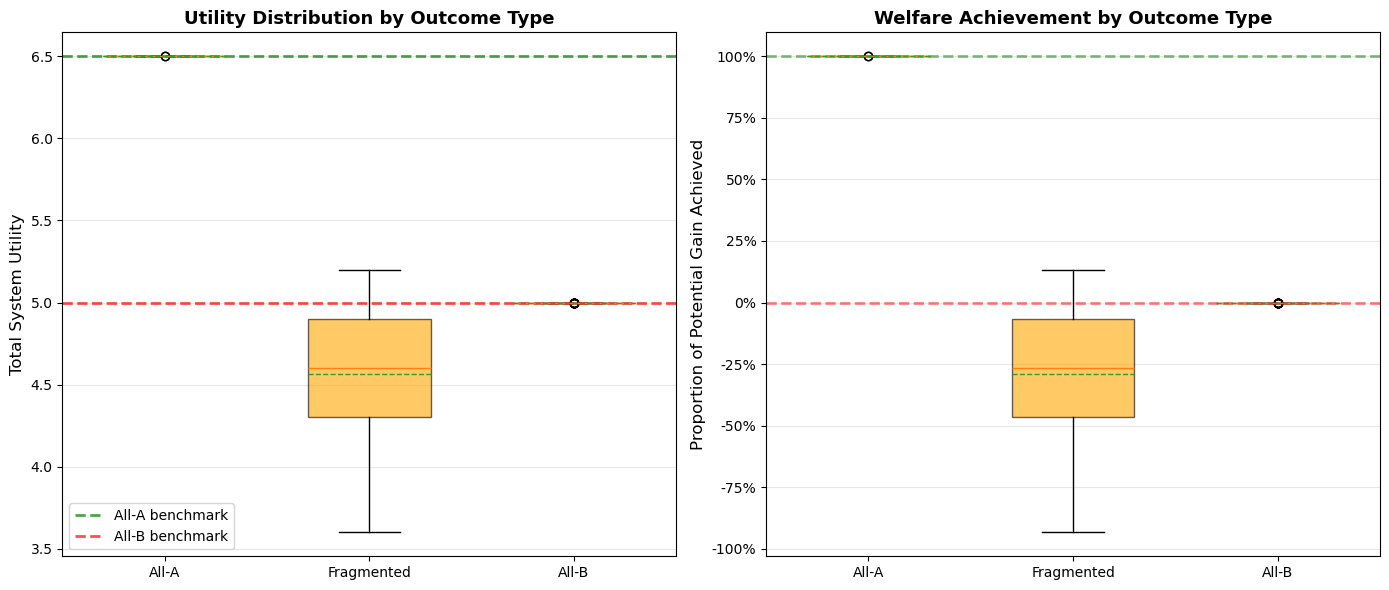


UTILITY ANALYSIS ACROSS SCALES

Weak coupling: a=0.5, c=0.6
------------------------------------------------------------
  n= 2: Avg utility achieved = -52.2%, All-A = 24.6%
  n= 4: Avg utility achieved = -67.6%, All-A = 6.6%
  n= 6: Avg utility achieved = -66.5%, All-A = 1.8%
  n= 8: Avg utility achieved = -65.3%, All-A = 0.2%
  n=10: Avg utility achieved = -65.7%, All-A = 0.0%

Strong coupling: a=2.0, c=0.6
------------------------------------------------------------
  n= 2: Avg utility achieved = 39.9%, All-A = 43.2%
  n= 4: Avg utility achieved = 36.7%, All-A = 19.8%
  n= 6: Avg utility achieved = 37.5%, All-A = 9.0%
  n= 8: Avg utility achieved = 36.8%, All-A = 3.2%
  n=10: Avg utility achieved = 36.9%, All-A = 1.4%

Generating utility achievement across scales...


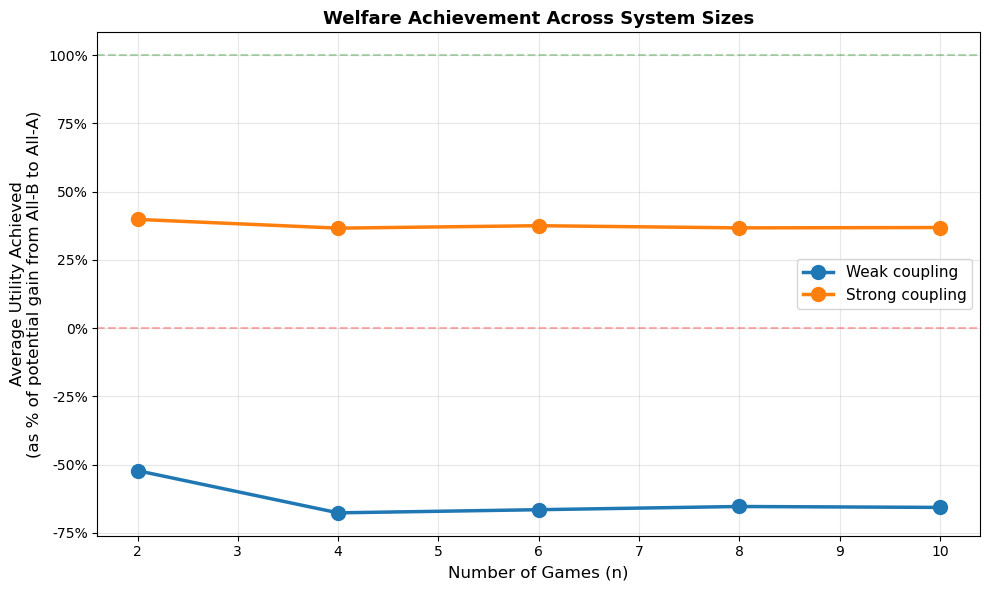


   First test (n=5, a=1.0, c=0.3):
   - Fragmented outcomes: 79.8% of trials
   - Average utility achieved: -29.1%
   - This is worse than staying at all-B

   - All-A outcomes: 3.9% of trials
   - Average utility achieved: 100.0%
   - But this only happens 3.9% of the time.

   - All-B outcomes: 16.3% of trials
   - These achieve 0% by definition (the baseline)


In [8]:
"""BLOCK 10: UTILITY ANALYSIS - IS PARTIAL COORDINATION GOOD ENOUGH?"""

print_section_header(
    "Utility Analysis: Evaluating Welfare of Coordination Outcomes",
    "Testing whether partial coordination delivers sufficient welfare gains"
)

print("Objection: Maybe we're too focused on all-A optimality. Perhaps partial")
print("coordination (fragmented outcomes) still delivers high utility compared to all-B.")
print()
print("We'll test this claim, using all-B as the baseline.")
print()

class UtilityEvaluator:
    """
    Compute welfare/utility for outcomes in n-game coordination systems.
    
    For a single game at state x (proportion playing A):
        - A-players receive: α * x (payoff from coordinating with A-players)
        - B-players receive: β * (1-x) (payoff from coordinating with B-players)
        - Average utility: x(αx) + (1-x)(β(1-x)) = αx² + β(1-x)²
    
    For interdependent games:
        - α_i depends on states of neighboring games
        - Compute average utility for each game, then aggregate
    """
    
    @staticmethod
    def compute_game_utility(x: float, alpha: float, beta: float) -> float:
        """
        Compute average utility in a single game at state x.
        
        Parameters:
        -----------
        x : float
            Proportion playing A
        alpha : float
            Payoff parameter for A-coordination
        beta : float
            Payoff parameter for B-coordination
        
        Returns:
        --------
        float : Average utility per player
        """
        utility_A_players = alpha * x
        utility_B_players = beta * (1 - x)
        average_utility = x * utility_A_players + (1 - x) * utility_B_players
        return average_utility
    
    @staticmethod
    def compute_system_utility(x_final: np.ndarray, model: NGameCoordinationSystem) -> dict:
        """
        Compute utilities for a final state in n-game system.
        
        Returns:
        --------
        dict with:
            'total_utility': sum of utilities across all games
            'average_utility': mean utility per game
            'game_utilities': array of utilities for each game
            'all_A_utility': utility if all games were at all-A
            'all_B_utility': utility if all games were at all-B
            'utility_achieved': proportion of potential gain (all-B to all-A) achieved
        """
        n = model.n
        game_utilities = np.zeros(n)
        
        # Compute utility for each game given final state
        for i in range(n):
            alpha_i = model.compute_alpha(x_final, i)
            game_utilities[i] = UtilityEvaluator.compute_game_utility(
                x_final[i], alpha_i, model.beta
            )
        
        total_utility = np.sum(game_utilities)
        average_utility = np.mean(game_utilities)
        
        # Compute benchmark utilities
        # All-A: x = 1 for all games
        x_all_A = np.ones(n)
        all_A_utility = 0
        for i in range(n):
            alpha_i = model.compute_alpha(x_all_A, i)
            all_A_utility += UtilityEvaluator.compute_game_utility(1.0, alpha_i, model.beta)
        
        # All-B: x = 0 for all games
        x_all_B = np.zeros(n)
        all_B_utility = 0
        for i in range(n):
            alpha_i = model.compute_alpha(x_all_B, i)
            all_B_utility += UtilityEvaluator.compute_game_utility(0.0, alpha_i, model.beta)
        
        # Compute proportion of potential gain achieved
        if all_A_utility > all_B_utility:
            utility_achieved = (total_utility - all_B_utility) / (all_A_utility - all_B_utility)
        else:
            utility_achieved = 0.0
        
        return {
            'total_utility': total_utility,
            'average_utility': average_utility,
            'game_utilities': game_utilities,
            'all_A_utility': all_A_utility,
            'all_B_utility': all_B_utility,
            'utility_achieved': utility_achieved
        }

# Test utility differences across outcome types
print("UTILITY COMPARISON: Outcome Types")
print("="*80)

# Configuration: n=5 games, moderate coupling
n_test = 5
a_test = 1.0
c_test = 0.3
beta_test = 1.0

model_utility = NGameCoordinationSystem(
    n_games=n_test,
    alpha_coupling=a_test,
    constant=c_test,
    beta=beta_test,
    within_correlation=0.0
)

print(f"System: n={n_test} games, a={a_test}, c={c_test}, β={beta_test}")
print()

# Benchmark utilities
x_all_A = np.ones(n_test)
x_all_B = np.zeros(n_test)

util_all_A = UtilityEvaluator.compute_system_utility(x_all_A, model_utility)
util_all_B = UtilityEvaluator.compute_system_utility(x_all_B, model_utility)

print(f"Benchmark Utilities:")
print(f"  All-A: {util_all_A['total_utility']:.3f} (average per game: {util_all_A['average_utility']:.3f})")
print(f"  All-B: {util_all_B['total_utility']:.3f} (average per game: {util_all_B['average_utility']:.3f})")
print(f"  Potential gain (All-A over All-B): {util_all_A['total_utility'] - util_all_B['total_utility']:.3f}")
print()

# Sample different outcome types and compute utilities
print("Sampling outcomes and computing utilities...")
print("-"*60)

n_samples = 1000
np.random.seed(RANDOM_SEED)

outcome_utilities = {
    'All-A': [],
    'All-B': [],
    'Fragmented': [],
    'Mixed': []
}

for _ in range(n_samples):
    x0 = np.random.uniform(0, 1, n_test)
    t, x = model_utility.simulate(x0, T=100)
    x_final = x[-1]
    
    outcome_type = model_utility.classify_outcome(x_final)
    utility_result = UtilityEvaluator.compute_system_utility(x_final, model_utility)
    
    outcome_utilities[outcome_type].append(utility_result)

# Compute statistics for each outcome type
print(f"{'Outcome Type':<15} {'Count':<8} {'Avg Utility':<15} {'Utility Achieved':<20}")
print("="*80)

for outcome_type in ['All-A', 'Fragmented', 'Mixed', 'All-B']:
    if outcome_utilities[outcome_type]:
        count = len(outcome_utilities[outcome_type])
        avg_util = np.mean([u['total_utility'] for u in outcome_utilities[outcome_type]])
        avg_achieved = np.mean([u['utility_achieved'] for u in outcome_utilities[outcome_type]])
        
        print(f"{outcome_type:<15} {count:<8} {avg_util:<15.3f} {avg_achieved:<20.1%}")
    else:
        print(f"{outcome_type:<15} {0:<8} {'N/A':<15} {'N/A':<20}")

# Visualize utility distributions
print("\nGenerating utility distribution visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Utility distributions by outcome type
outcome_types_present = [ot for ot in ['All-A', 'Fragmented', 'Mixed', 'All-B'] 
                         if outcome_utilities[ot]]
positions = range(len(outcome_types_present))
colors_box = ['green', 'orange', 'gray', 'red']

utility_data = []
colors_used = []
for idx, outcome_type in enumerate(outcome_types_present):
    utils = [u['total_utility'] for u in outcome_utilities[outcome_type]]
    utility_data.append(utils)
    colors_used.append(colors_box[['All-A', 'Fragmented', 'Mixed', 'All-B'].index(outcome_type)])

bp = ax1.boxplot(utility_data, positions=positions, widths=0.6, patch_artist=True,
                 showmeans=True, meanline=True)

for patch, color in zip(bp['boxes'], colors_used):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax1.set_xticks(positions)
ax1.set_xticklabels(outcome_types_present)
ax1.set_ylabel('Total System Utility', fontsize=12)
ax1.set_title('Utility Distribution by Outcome Type', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Add benchmark lines
ax1.axhline(util_all_A['total_utility'], color='green', linestyle='--', 
            linewidth=2, alpha=0.7, label='All-A benchmark')
ax1.axhline(util_all_B['total_utility'], color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label='All-B benchmark')
ax1.legend(fontsize=10)

# Plot 2: Utility achieved (proportion of potential gain)
achieved_data = []
for outcome_type in outcome_types_present:
    achieved = [u['utility_achieved'] for u in outcome_utilities[outcome_type]]
    achieved_data.append(achieved)

bp2 = ax2.boxplot(achieved_data, positions=positions, widths=0.6, patch_artist=True,
                  showmeans=True, meanline=True)

for patch, color in zip(bp2['boxes'], colors_used):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_xticks(positions)
ax2.set_xticklabels(outcome_types_present)
ax2.set_ylabel('Proportion of Potential Gain Achieved', fontsize=12)
ax2.set_title('Welfare Achievement by Outcome Type', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(1.0, color='green', linestyle='--', linewidth=2, alpha=0.5)
ax2.axhline(0.0, color='red', linestyle='--', linewidth=2, alpha=0.5)

plt.tight_layout()
plt.show()

# Analyze scale effects with utility
print("\n" + "="*80)
print("UTILITY ANALYSIS ACROSS SCALES")
print("="*80)

scale_configs_utility = [
    {'a': 0.5, 'c': 0.6, 'label': 'Weak coupling'},
    {'a': 2.0, 'c': 0.6, 'label': 'Strong coupling'}
]

n_values_utility = [2, 4, 6, 8, 10]
n_trials_utility = 500

utility_scale_results = {}

for config in scale_configs_utility:
    print(f"\n{config['label']}: a={config['a']}, c={config['c']}")
    print("-"*60)
    
    results_by_n = {}
    
    for n in n_values_utility:
        model = NGameCoordinationSystem(
            n_games=n,
            alpha_coupling=config['a'],
            constant=config['c'],
            beta=1.0,
            within_correlation=0.0
        )
        
        # Sample outcomes and compute utilities
        utilities_achieved = []
        outcome_counts = {'All-A': 0, 'All-B': 0, 'Fragmented': 0, 'Mixed': 0}
        
        np.random.seed(RANDOM_SEED)
        for _ in range(n_trials_utility):
            x0 = np.random.uniform(0, 1, n)
            t, x = model.simulate(x0, T=100)
            x_final = x[-1]
            
            outcome_type = model.classify_outcome(x_final)
            outcome_counts[outcome_type] += 1
            
            utility_result = UtilityEvaluator.compute_system_utility(x_final, model)
            utilities_achieved.append(utility_result['utility_achieved'])
        
        avg_utility_achieved = np.mean(utilities_achieved)
        
        results_by_n[n] = {
            'avg_utility_achieved': avg_utility_achieved,
            'outcome_counts': outcome_counts,
            'utilities': utilities_achieved
        }
        
        print(f"  n={n:2d}: Avg utility achieved = {avg_utility_achieved:.1%}, "
              f"All-A = {outcome_counts['All-A']/n_trials_utility:.1%}")
    
    utility_scale_results[config['label']] = results_by_n

# Visualize utility achievement across scales
print("\nGenerating utility achievement across scales...")

fig, ax = plt.subplots(figsize=(10, 6))

for config in scale_configs_utility:
    label = config['label']
    results = utility_scale_results[label]
    
    n_vals = sorted(results.keys())
    avg_achieved = [results[n]['avg_utility_achieved'] for n in n_vals]
    
    ax.plot(n_vals, avg_achieved, marker='o', markersize=10,
            linewidth=2.5, label=label)

ax.set_xlabel('Number of Games (n)', fontsize=12)
ax.set_ylabel('Average Utility Achieved\n(as % of potential gain from All-B to All-A)', 
              fontsize=12)
ax.set_title('Welfare Achievement Across System Sizes', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.axhline(1.0, color='green', linestyle='--', linewidth=1.5, alpha=0.3)
ax.axhline(0.0, color='red', linestyle='--', linewidth=1.5, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze the first test in detail
if outcome_utilities['Fragmented']:
    frag_utils = [u['utility_achieved'] for u in outcome_utilities['Fragmented']]
    print(f"\n   First test (n=5, a=1.0, c=0.3):")
    print(f"   - Fragmented outcomes: {len(outcome_utilities['Fragmented'])/n_samples:.1%} of trials")
    print(f"   - Average utility achieved: {np.mean(frag_utils):.1%}")
    print(f"   - This is worse than staying at all-B")
    
if outcome_utilities['All-A']:
    all_a_utils = [u['utility_achieved'] for u in outcome_utilities['All-A']]
    print(f"\n   - All-A outcomes: {len(outcome_utilities['All-A'])/n_samples:.1%} of trials")
    print(f"   - Average utility achieved: {np.mean(all_a_utils):.1%}")
    print(f"   - But this only happens {len(outcome_utilities['All-A'])/n_samples:.1%} of the time.")

if outcome_utilities['All-B']:
    print(f"\n   - All-B outcomes: {len(outcome_utilities['All-B'])/n_samples:.1%} of trials")
    print(f"   - These achieve 0% by definition (the baseline)")